
# **<font color='purple'> `Part 1: Data Collection and Preprocessing`</font>**
***
**Student**


|         Full name         |   Username  |         Email         |
|---------------------------|-------------|-----------------------|
| Emmanuel Nyandu Kagarabi  | emmanuelnk  | emmanuelnk@aims.ac.za |

<font color='teal'>`AI-Powered Classification and Early Detection of Dengue Lineages for a Timely Public Health Response`</font>

# `0. Imports`

In [ ]:
# Installations
!pip install Bio
!pip install prince
!pip install imbalanced-learn
!pip install pandas biopython
!pip install scikit-learn
!pip install xgboost
!pip install hiclass
!pip install mmh3
!pip install keras-self-attention
# Clean installation outputs`
from IPython.display import clear_output
clear_output()

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input, Conv1D,Conv2D,MaxPooling1D,MaxPooling2D, Flatten,BatchNormalization,GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.preprocessing.sequence import pad_sequences
import requests
from Bio import SeqIO, Phylo
import prince
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter
import re
import os
import zipfile
from sklearn import tree
from scipy.fftpack import fft
import mmh3
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, roc_curve, auc, classification_report)
from xgboost import XGBClassifier
import lightgbm as lgb
from hiclass import (LocalClassifierPerNode, LocalClassifierPerParentNode, LocalClassifierPerLevel)
#from sklearn.utils.multiclass import unique_label
from scipy.stats import entropy
from datetime import datetime
from random import shuffle
import joblib
%matplotlib inline
import time
from keras_self_attention import SeqSelfAttention #Import the SeqSelfAttention layer
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Random Sampling
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from itertools import cycle

import warnings
warnings.filterwarnings("ignore")

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

now = datetime.now()
now.strftime("%H:%M:%S")

Num GPUs Available:  2


'18:01:49'

# `I. Data exploration`

# `I.1. Minor Lineages`

In [ ]:
df_minor_lineages = pd.read_csv('/content/FINAL_DATASET/DEADLINE_RESULTS/minor_lineages.csv')
df_minor_lineages.head(64)

,Minor Lineage,Most Common Region,Oldest Date
0,1I_E.1,Southeast Asia,2015-01-01
1,1I_E.2,Pacific,2016-02-01
2,1I_H.1,Southeast Asia,2006-01-01
3,1I_H.2,Southeast Asia,2006-01-01
4,1I_K.1,East Asia,2014-01-01
...,...,...,...
59,4I_A.3,Southeast Asia,2002-01-01
60,4I_B.1,South Asia,2009-01-01
61,4I_B.2,South Asia,2009-01-01
62,4II_A.1,Southeast Asia,2017-01-01


In [ ]:
df_minor_lineages.describe().T

,count,unique,top,freq
Minor Lineage,64,64,1I_E.1,1
Most Common Region,64,9,Southeast Asia,28
Oldest Date,64,39,2009-01-01,6


In [ ]:
df_minor_lineages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Minor Lineage       64 non-null     object
 1   Most Common Region  64 non-null     object
 2   Oldest Date         64 non-null     object
dtypes: object(3)
memory usage: 1.6+ KB


In [ ]:
# All recognised lineages
df_minor_lineages['Minor Lineage'].unique()

array(['1I_E.1', '1I_E.2', '1I_H.1', '1I_H.2', '1I_K.1', '1I_K.2',
       '1I_K.3', '1IV_B.1', '1IV_B.2', '1V_D.1', '1V_D.2', '2II_A.1',
       '2II_A.2.1', '2II_A.2.2', '2II_C.1', '2II_C.2', '2II_D.1',
       '2II_D.2', '2II_D.3', '2II_E.1', '2II_E.2', '2II_F.1', '2II_F.1.1',
       '2II_F.1.2', '2II_F.2', '2II_F.2.1', '2II_F.2.2', '2III_A.1',
       '2III_A.2', '2III_C.1', '2III_C.1.1', '2III_C.1.2', '2III_C.2',
       '2III_D.1', '2III_D.1.1', '2III_D.1.2', '2III_D.1.3', '2III_D.2',
       '2III_D.3', '2V_A.1', '2V_A.2', '2V_A.3', '2V_A.4', '3I_A.1',
       '3I_A.2', '3II_A.1', '3II_A.2', '3II_A.3', '3III_A.1', '3III_A.2',
       '3III_B.1', '3III_B.2', '3III_B.3', '3III_C.1', '3III_C.2',
       '4I_A.1', '4I_A.1.1', '4I_A.1.2', '4I_A.2', '4I_A.3', '4I_B.1',
       '4I_B.2', '4II_A.1', '4II_A.2'], dtype=object)

In [ ]:
df_minor_lineages['Minor Lineage'].count()

64

`Overall, we have 64 lineages.`

# `I.2.  Genomic sequences`

| `Serotype` | `GISAID samples` | `Samples after cleaning` |
|----------|----------------|------------------------|
| DENV1    | 3891           | 1509                       |
| DENV2    | 2553           | 1122                       |
| DENV3    | 877            | 737                    |
| DENV4    | 371            | 206                    |
| **Total**|  **7692**              |     **3574**           |


In [ ]:
def process_dengue_data(metadata1_path, metadata2_path, results_csv_path, results_fasta_path, replacement_dict=None):

    def merge_dataframes(df1, df2, how='inner'):
        common_columns = df1.columns.intersection(df2.columns).tolist()
        return pd.merge(df1, df2, on=common_columns, how=how)

    def fasta_to_dataframe(fasta_file):
        records = []
        for record in SeqIO.parse(fasta_file, 'fasta'):
            records.append({
                'Virus name': record.description,
                'Sequence': str(record.seq)
            })
        df = pd.DataFrame(records)
        df['Virus name'] = df['Virus name'].str.replace('[^a-zA-Z0-9]', '', regex=True)
        return df

    def merge_based_on_substring(df1, df2):
        df2['Full_Virus_Name'] = None
        for index, row in df2.iterrows():
            w2 = row['Virus name']
            matches = df1[df1['Virus name'].str.contains(w2, case=False, na=False)]
            if not matches.empty:
                df2.at[index, 'Full_Virus_Name'] = matches.iloc[0]['Virus name']
            else:
                print(f"{w2} missed its original name")
        merged_df = pd.merge(df2, df1, left_on='Full_Virus_Name', right_on='Virus name', how='left', suffixes=('_df2', '_df1'))
        merged_df = merged_df.drop('Full_Virus_Name', axis=1)
        return merged_df

    # Step 1: Merge metadata files
    metadata1 = pd.read_csv(metadata1_path, sep='\t')# , sep='\t'
    metadata2 = pd.read_csv(metadata2_path, sep='\t')#, sep='\t'
    metadata = merge_dataframes(metadata1, metadata2, how='inner')
    metadata = metadata[['Virus name', 'Accession ID', 'Collection date', 'Submission date', 'Location']]
    metadata['Virus name'] = metadata['Virus name'] + metadata['Accession ID']
    metadata['Virus name'] = metadata['Virus name'].str.replace('[^a-zA-Z0-9]', '', regex=True)

    # Step 2: Process results files
    results = pd.read_csv(results_csv_path)
    results.rename(columns={'name': 'Virus name'}, inplace=True)
    results['Virus name'] = results['Virus name'].str.replace('[^a-zA-Z0-9]', '', regex=True)
    results = results[['Virus name', 'species', 'assignment', 'type', 'major lineage', 'minor lineage', 'minor lineage.1']]

    fasta_df = fasta_to_dataframe(results_fasta_path)
    results_merged = merge_dataframes(results, fasta_df, how='inner')

    # Step 3: Final merge
    if replacement_dict is not None:
        # Replace old values with new values in results_merged
        results_merged['Virus name'] = results_merged['Virus name'].replace(replacement_dict)

    final_df = merge_based_on_substring(metadata, results_merged)
    final_df = final_df[['Accession ID', 'Sequence', 'species', 'assignment', 'type', 'major lineage', 'minor lineage', 'minor lineage.1', 'Collection date', 'Submission date', 'Location']]

    # Rename species content
    #serotype = re.search(r'DENV\d', metadata1_path).group()
    #final_df['species'] = final_df['species'].str.replace(f'dengue virus type {serotype[-1]}', serotype)

    # Filter by correct lineages
    correct_lineages = final_df['assignment'].isin(df_minor_lineages['Minor Lineage'])
    final_df = final_df[correct_lineages]

    # Final column selection and renaming
    final_df = final_df[['Sequence','species', 'assignment', 'Collection date', 'Submission date', 'Location']]
    final_df.rename(columns={'assignment': 'Lineage'}, inplace=True)

    return final_df

In [ ]:
def split_and_save_df(df, threshold, folder_path):
    """
    Split a dataframe based on a threshold number of rows and save the resulting dataframes.

    Parameters:
    df (pandas.DataFrame): Input dataframe
    threshold (int): Number of rows for the first dataframe
    folder_path (str): Path to save the resulting dataframes

    Returns:
    tuple: (df1, df2) - The two resulting dataframes
    """
    # Split the dataframe
    df1 = df.iloc[:threshold]
    df2 = df.iloc[threshold:]

    # Create folder if it doesn't exist
    #os.makedirs(folder_path, exist_ok=True)

    # Save dataframes
    df1.to_csv(os.path.join(folder_path, 'df_first_part.csv'), index=False)
    df2.to_csv(os.path.join(folder_path, 'df_second_part.csv'), index=False)

    return df1, df2

def concatenate_shuffle_save(num_dfs, *dfs, folder_path):
    """
    Concatenate multiple dataframes, shuffle the rows, and save the result.

    Parameters:
    num_dfs (int): Number of dataframes to concatenate
    *dfs: Variable number of dataframes to concatenate
    folder_path (str): Path to save the resulting dataframe

    Returns:
    pandas.DataFrame: The final concatenated and shuffled dataframe
    """
    # Ensure the correct number of dataframes are provided
    if len(dfs) != num_dfs:
        raise ValueError(f"Expected {num_dfs} dataframes, but got {len(dfs)}")

    # Concatenate dataframes
    final_df = pd.concat(dfs, ignore_index=True)

    # Shuffle rows
    final_df = final_df.sample(frac=1).reset_index(drop=True)

    # Save the final dataframe
    final_df.to_csv(os.path.join(folder_path, 'final_shuffled_df.csv'), index=False)

    return final_df

**A. DENV1**

In [ ]:
# @title
#Detective truncations
truncations11 = {
    'hDenV1BrazilPRFiocruzLRV23H10': 'hDenV1BrazilPRFiocruzLRV23H12822',
    'hDenV1BrazilPRFiocruzLRV23H11': 'hDenV1BrazilPRFiocruzLRV23H12482',
    'hDenV1BrazilSCFiocruzLRV24H10': 'hDenV1BrazilSCFiocruzLRV24H1672',
    'hDenV1BrazilSCFiocruzLRV24H11': 'hDenV1BrazilSCFiocruzLRV24H1662',
    'hDenV1BrazilSCFiocruzLRV24H12': 'hDenV1BrazilSCFiocruzLRV24H1622',
    'hDenV1BrazilSCFiocruzLRV24H13': 'hDenV1BrazilSCFiocruzLRV24H1642',
    'hDenV1BrazilSCFiocruzLRV24H14': 'hDenV1BrazilSCFiocruzLRV24H1582',
    'hDenV1BrazilSCFiocruzLRV24H15': 'hDenV1BrazilSCFiocruzLRV24H1692',
    'hDenV1BrazilSCFiocruzLRV24H16': 'hDenV1BrazilSCFiocruzLRV24H1542',
    'hDenV1BrazilSCFiocruzLRV24H17': 'hDenV1BrazilSCFiocruzLRV24H1592',
    'hDenV1BrazilSCFiocruzLRV24H18': 'hDenV1BrazilSCFiocruzLRV24H1682',
    'hDenV1BrazilSCFiocruzLRV24H19': 'hDenV1BrazilSCFiocruzLRV24H1572',
    'hDenV1BrazilPRFiocruzLRV23H12': 'hDenV1BrazilPRFiocruzLRV23H12522',
    'hDenV1BrazilPRFiocruzLRV23H13': 'hDenV1BrazilPRFiocruzLRV23H12622',
    'hDenV1BrazilPRFiocruzLRV23H14': 'hDenV1BrazilPRFiocruzLRV23H12732',
    'hDenV1BrazilPRFiocruzLRV23H15': 'hDenV1BrazilPRFiocruzLRV23H12432',
    'hDenV1BrazilPRFiocruzLRV23H16': 'hDenV1BrazilPRFiocruzLRV23H12402',
    'hDenV1BrazilPRFiocruzLRV23H17': 'hDenV1BrazilPRFiocruzLRV23H12612',
    'hDenV1BrazilPRFiocruzLRV23H18': 'hDenV1BrazilPRFiocruzLRV23H12592',
    'hDenV1BrazilPRFiocruzLRV23H19': 'hDenV1BrazilPRFiocruzLRV23H12772',
    'hDenV1BrazilPEFIOCRUZIAM16180': 'hDenV1BrazilPEFIOCRUZIAM161872',
    'hDenV1BrazilPEFIOCRUZIAM16181': 'hDenV1BrazilPEFIOCRUZIAM161852',
    'hDenV1BrazilPEFIOCRUZIAM16182': 'hDenV1BrazilPEFIOCRUZIAM161862',
    'hDenV1BrazilPEFIOCRUZIAM16190': 'hDenV1BrazilPEFIOCRUZIAM161912',
    'hDenV1BrazilPEFIOCRUZIAM16191': 'hDenV1BrazilPEFIOCRUZIAM161952',
    'hDenV1BrazilPEFIOCRUZIAM16192': 'hDenV1BrazilPEFIOCRUZIAM161992',
    'hDenV1BrazilPEFIOCRUZIAM16193': 'hDenV1BrazilPEFIOCRUZIAM161972',
    'hDenV1BrazilPEFIOCRUZIAM16194': 'hDenV1BrazilPEFIOCRUZIAM161942',
    'hDenV1BrazilPEFIOCRUZIAM16200': 'hDenV1BrazilPEFIOCRUZIAM162002',
    'hDenV1BrazilPEFIOCRUZIAM16201': 'hDenV1BrazilPEFIOCRUZIAM162012',
    'hDenV1BrazilPEFIOCRUZIAM16202': 'hDenV1BrazilPEFIOCRUZIAM162032',
    'hDenV1BrazilPEFIOCRUZIAM16203': 'hDenV1BrazilPEFIOCRUZIAM162062',
    'hDenV1BrazilPEFIOCRUZIAM16204': 'hDenV1BrazilPEFIOCRUZIAM162042',
    'hDenV1BrazilPEFIOCRUZIAM16210': 'hDenV1BrazilPEFIOCRUZIAM162112',
    'hDenV1BrazilPEFIOCRUZIAM16211': 'hDenV1BrazilPEFIOCRUZIAM162152',
    'hDenV1BrazilSCLACENSC42154610': 'hDenV1BrazilSCLACENSC42154612',
    'hDenV1BrazilSCLACENSC42154611': 'hDenV1BrazilSCLACENSC42154617',
    'hDenV1BrazilSCLACENSC42155130': 'hDenV1BrazilSCLACENSC42155132',
    'hDenV1BrazilSCLACENSC42155131': 'hDenV1BrazilSCLACENSC42155135',
    'hDenV1BrazilPEFIOCRUZIAM17050': 'hDenV1BrazilPEFIOCRUZIAM170532',
    'hDenV1BrazilPEFIOCRUZIAM17051': 'hDenV1BrazilPEFIOCRUZIAM170512',
    'hDenV1BrazilPEFIOCRUZIAM17052': 'hDenV1BrazilPEFIOCRUZIAM170542',
    'hDenV1BrazilPEFIOCRUZIAM17053': 'hDenV1BrazilPEFIOCRUZIAM170522',
    'hDenV1BrazilPEFIOCRUZIAM17054': 'hDenV1BrazilPEFIOCRUZIAM170562',
    'hDenV1BrazilPEFIOCRUZIAM17055': 'hDenV1BrazilPEFIOCRUZIAM170552',
    'hDenV1BrazilPRFiocruzLRV23H110': 'hDenV1BrazilPRFiocruzLRV23H12702023',
    'hDenV1BrazilPRFiocruzLRV23H111': 'hDenV1BrazilPRFiocruzLRV23H12412023',
    'hDenV1BrazilPRFiocruzLRV23H112': 'hDenV1BrazilPRFiocruzLRV23H12552023',
    'hDenV1BrazilPRFiocruzLRV23H113': 'hDenV1BrazilPRFiocruzLRV23H12392023',
    'hDenV1BrazilPRFiocruzLRV23H114': 'hDenV1BrazilPRFiocruzLRV23H12602023',
    'hDenV1BrazilPRFiocruzLRV23H115': 'hDenV1BrazilPRFiocruzLRV23H12422023',
    'hDenV1BrazilPRFiocruzLRV23H116': 'hDenV1BrazilPRFiocruzLRV23H12462023',
    'hDenV1BrazilPRFiocruzLRV23H117': 'hDenV1BrazilPRFiocruzLRV23H12452023',
    'hDenV1BrazilPRFiocruzLRV23H118': 'hDenV1BrazilPRFiocruzLRV23H12562023',
    'hDenV1BrazilPRFiocruzLRV23H119': 'hDenV1BrazilPRFiocruzLRV23H12542023',
    'hDenV1BrazilPRFiocruzLRV23H120': 'hDenV1BrazilPRFiocruzLRV23H12532023',
    'hDenV1BrazilPRFiocruzLRV23H121': 'hDenV1BrazilPRFiocruzLRV23H12652023',
    'hDenV1BrazilPRFiocruzLRV23H122': 'hDenV1BrazilPRFiocruzLRV23H12812023',
    'hDenV1BrazilPRFiocruzLRV23H123': 'hDenV1BrazilPRFiocruzLRV23H12802023',
    'hDenV1BrazilPRFiocruzLRV23H124': 'hDenV1BrazilPRFiocruzLRV23H12672023',
    'hDenV1BrazilPRFiocruzLRV23H125': 'hDenV1BrazilPRFiocruzLRV23H12722023',
    'hDenV1BrazilPRFiocruzLRV23H126': 'hDenV1BrazilPRFiocruzLRV23H12712023',
    'hDenV1BrazilPRFiocruzLRV23H127': 'hDenV1BrazilPRFiocruzLRV23H12572023',
    'hDenV1ColombiaVACLSPVAC240020': 'hDenV1ColombiaVACLSPVAC2400227',
    'hDenV1ColombiaVACLSPVAC240021': 'hDenV1ColombiaVACLSPVAC2400298',
    'hDenV1ColombiaVACLSPVAC240550': 'hDenV1ColombiaVACLSPVAC2405525',
    'hDenV1ColombiaVACLSPVAC240551': 'hDenV1ColombiaVACLSPVAC2405553',
    'hDenV1BrazilESLACENES32148240': 'hDenV1BrazilESLACENES321482486202',
    'hDenV1BrazilESLACENES32148241': 'hDenV1BrazilESLACENES321482438202',
    'hDenV1BrazilPEFIOCRUZIAM17040': 'hDenV1BrazilPEFIOCRUZIAM170422024',
    'hDenV1BrazilPEFIOCRUZIAM17041': 'hDenV1BrazilPEFIOCRUZIAM170452024',
    'hDenV1BrazilPEFIOCRUZIAM17042': 'hDenV1BrazilPEFIOCRUZIAM170472024',
    'hDenV1BrazilPEFIOCRUZIAM17043': 'hDenV1BrazilPEFIOCRUZIAM170402024',
    'hDenV1BrazilPEFIOCRUZIAM17030': 'hDenV1BrazilPEFIOCRUZIAM170312024',
    'hDenV1BrazilPEFIOCRUZIAM17031': 'hDenV1BrazilPEFIOCRUZIAM170392024',
    'hDenV1BrazilPEFIOCRUZIAM17032': 'hDenV1BrazilPEFIOCRUZIAM170302024',
    'hDenV1BrazilPEFIOCRUZIAM17033': 'hDenV1BrazilPEFIOCRUZIAM170332024',
    'hDenV1BrazilPEFIOCRUZIAM17034': 'hDenV1BrazilPEFIOCRUZIAM170362024',
    'hDenV1BrazilPEFIOCRUZIAM17035': 'hDenV1BrazilPEFIOCRUZIAM170352024',
    'hDenV1BrazilPEFIOCRUZIAM17036': 'hDenV1BrazilPEFIOCRUZIAM170372024',
    'hDenV1BrazilPEFIOCRUZIAM17037': 'hDenV1BrazilPEFIOCRUZIAM170342024',
    'hDenV1EcuadorGENSBIOINSPI2780': 'hDenV1EcuadorGENSBIOINSPI27880524',
    'hDenV1EcuadorGENSBIOINSPI2781': 'hDenV1EcuadorGENSBIOINSPI27870524',
    'hDenV1EcuadorGENSBIOINSPI2782': 'hDenV1EcuadorGENSBIOINSPI27850524',
    'hDenV1ColombiaVACLSPVAC240570': 'hDenV1ColombiaVACLSPVAC24057312024',
    'hDenV1ColombiaVACLSPVAC240571': 'hDenV1ColombiaVACLSPVAC24057542024',
    'hDenV1ColombiaVACLSPVAC240572': 'hDenV1ColombiaVACLSPVAC24057742024',
    'hDenV1BrazilSCFiocruzLRV24H110': 'hDenV1BrazilSCFiocruzLRV24H19512024',
    'hDenV1BrazilSCFiocruzLRV24H111': 'hDenV1BrazilSCFiocruzLRV24H19422024',
    'hDenV1BrazilSCFiocruzLRV24H112': 'hDenV1BrazilSCFiocruzLRV24H19622024',
    'hDenV1BrazilSCFiocruzLRV24H113': 'hDenV1BrazilSCFiocruzLRV24H19452024',
    'hDenV1BrazilSCFiocruzLRV24H114': 'hDenV1BrazilSCFiocruzLRV24H19502024',
    'hDenV1BrazilSCFiocruzLRV24H115': 'hDenV1BrazilSCFiocruzLRV24H19462024',
    'hDenV1BrazilSCFiocruzLRV24H116': 'hDenV1BrazilSCFiocruzLRV24H19552024',
    'hDenV1BrazilPRFiocruzLRV24H60': 'hDenV1BrazilPRFiocruzLRV24H6092024',
    'hDenV1BrazilPRFiocruzLRV24H61': 'hDenV1BrazilPRFiocruzLRV24H6062024',
    'hDenV1BrazilPRFiocruzLRV24H62': 'hDenV1BrazilPRFiocruzLRV24H6142024',
    'hDenV1BrazilPRFiocruzLRV24H63': 'hDenV1BrazilPRFiocruzLRV24H6102024',
    'hDenV1BrazilPRFiocruzLRV24H64': 'hDenV1BrazilPRFiocruzLRV24H6162024',
    'hDenV1BrazilPRFiocruzLRV24H65': 'hDenV1BrazilPRFiocruzLRV24H6112024',
    'hDenV1BrazilPRFiocruzLRV24H66': 'hDenV1BrazilPRFiocruzLRV24H6182024',
    'hDenV1BrazilPRFiocruzLRV24H67': 'hDenV1BrazilPRFiocruzLRV24H6082024',
    'hDenV1BrazilPRFiocruzLRV24H68': 'hDenV1BrazilPRFiocruzLRV24H6192024',
    'hDenV1BrazilPRFiocruzLRV24H69': 'hDenV1BrazilPRFiocruzLRV24H6022024',
    'hDenV1BrazilPRFiocruzLRV24H610': 'hDenV1BrazilPRFiocruzLRV24H6242024',
    'hDenV1BrazilPRFiocruzLRV24H611': 'hDenV1BrazilPRFiocruzLRV24H6122024',
    'hDenV1BrazilPRFiocruzLRV24H612': 'hDenV1BrazilPRFiocruzLRV24H6012024',
    'hDenV1BrazilPRFiocruzLRV24H613': 'hDenV1BrazilPRFiocruzLRV24H6172024',
    'hDenV1BrazilPRFiocruzLRV24H614': 'hDenV1BrazilPRFiocruzLRV24H6262024',
    'hDenV1BrazilPRFiocruzLRV24H615': 'hDenV1BrazilPRFiocruzLRV24H6132024',
    'hDenV1BrazilPRFiocruzLRV24H616': 'hDenV1BrazilPRFiocruzLRV24H6002024',
    'hDenV1BrazilPRFiocruzLRV24H617': 'hDenV1BrazilPRFiocruzLRV24H6072024',
    'hDenV1BrazilPRFiocruzLRV24H618': 'hDenV1BrazilPRFiocruzLRV24H6202024',
    'hDenV1BrazilPRFiocruzLRV24H619': 'hDenV1BrazilPRFiocruzLRV24H6252024',
    'hDenV1BrazilPRFiocruzLRV24H620': 'hDenV1BrazilPRFiocruzLRV24H6032024',
    'hDenV1BrazilPRFiocruzLRV24H621': 'hDenV1BrazilPRFiocruzLRV24H6212024',
    'hDenV1BrazilPRFiocruzLRV24H622': 'hDenV1BrazilPRFiocruzLRV24H6042024',
    'hDenV1BrazilPRFiocruzLRV24H623': 'hDenV1BrazilPRFiocruzLRV24H6332024',
    'hDenV1BrazilPRFiocruzLRV24H624': 'hDenV1BrazilPRFiocruzLRV24H6572024',
    'hDenV1BrazilPRFiocruzLRV24H625': 'hDenV1BrazilPRFiocruzLRV24H6422024',
    'hDenV1BrazilPRFiocruzLRV24H626': 'hDenV1BrazilPRFiocruzLRV24H6872024',
    'hDenV1BrazilPRFiocruzLRV24H627': 'hDenV1BrazilPRFiocruzLRV24H6282024',
    'hDenV1BrazilPRFiocruzLRV24H628': 'hDenV1BrazilPRFiocruzLRV24H6542024',
    'hDenV1BrazilPRFiocruzLRV24H629': 'hDenV1BrazilPRFiocruzLRV24H6532024',
    'hDenV1BrazilPRFiocruzLRV24H630': 'hDenV1BrazilPRFiocruzLRV24H6442024',
    'hDenV1BrazilPRFiocruzLRV24H631': 'hDenV1BrazilPRFiocruzLRV24H6322024',
    'hDenV1BrazilPRFiocruzLRV24H632': 'hDenV1BrazilPRFiocruzLRV24H6472024',
    'hDenV1BrazilPRFiocruzLRV24H633': 'hDenV1BrazilPRFiocruzLRV24H6712024',
    'hDenV1BrazilPRFiocruzLRV24H634': 'hDenV1BrazilPRFiocruzLRV24H6912024',
    'hDenV1BrazilPRFiocruzLRV24H635': 'hDenV1BrazilPRFiocruzLRV24H6432024',
    'hDenV1BrazilPRFiocruzLRV24H636': 'hDenV1BrazilPRFiocruzLRV24H6552024',
    'hDenV1BrazilPRFiocruzLRV24H637': 'hDenV1BrazilPRFiocruzLRV24H6942024',
    'hDenV1BrazilPRFiocruzLRV24H638': 'hDenV1BrazilPRFiocruzLRV24H6522024',
    'hDenV1BrazilPRFiocruzLRV24H639': 'hDenV1BrazilPRFiocruzLRV24H6312024',
    'hDenV1BrazilPRFiocruzLRV24H640': 'hDenV1BrazilPRFiocruzLRV24H6292024',
    'hDenV1BrazilPRFiocruzLRV24H641': 'hDenV1BrazilPRFiocruzLRV24H6492024',
    'hDenV1BrazilPRFiocruzLRV24H642': 'hDenV1BrazilPRFiocruzLRV24H6822024',
    'hDenV1BrazilPRFiocruzLRV24H643': 'hDenV1BrazilPRFiocruzLRV24H6792024',
    'hDenV1BrazilPRFiocruzLRV24H644': 'hDenV1BrazilPRFiocruzLRV24H6812024',
    'hDenV1BrazilPRFiocruzLRV24H645': 'hDenV1BrazilPRFiocruzLRV24H6662024',
    'hDenV1BrazilPRFiocruzLRV24H646': 'hDenV1BrazilPRFiocruzLRV24H6702024',
    'hDenV1BrazilPRFiocruzLRV24H647': 'hDenV1BrazilPRFiocruzLRV24H6782024',
    'hDenV1BrazilPRFiocruzLRV24H648': 'hDenV1BrazilPRFiocruzLRV24H6772024',
    'hDenV1BrazilPRFiocruzLRV24H649': 'hDenV1BrazilPRFiocruzLRV24H6932024',
    'hDenV1BrazilPRFiocruzLRV24H650': 'hDenV1BrazilPRFiocruzLRV24H6672024',
    'hDenV1BrazilPRFiocruzLRV24H651': 'hDenV1BrazilPRFiocruzLRV24H6562024',
    'hDenV1BrazilPRFiocruzLRV24H652': 'hDenV1BrazilPRFiocruzLRV24H6342024',
    'hDenV1BrazilPRFiocruzLRV24H653': 'hDenV1BrazilPRFiocruzLRV24H6362024',
    'hDenV1BrazilPRFiocruzLRV24H654': 'hDenV1BrazilPRFiocruzLRV24H6302024',
    'hDenV1BrazilPRFiocruzLRV24H655': 'hDenV1BrazilPRFiocruzLRV24H6882024',
    'hDenV1BrazilPRFiocruzLRV24H656': 'hDenV1BrazilPRFiocruzLRV24H6802024',
    'hDenV1BrazilPRFiocruzLRV24H657': 'hDenV1BrazilPRFiocruzLRV24H6732024',
    'hDenV1BrazilPRFiocruzLRV24H658': 'hDenV1BrazilPRFiocruzLRV24H6402024',
    'hDenV1BrazilPRFiocruzLRV24H659': 'hDenV1BrazilPRFiocruzLRV24H6972024',
    'hDenV1BrazilPRFiocruzLRV24H660': 'hDenV1BrazilPRFiocruzLRV24H6722024',
    'hDenV1BrazilPRFiocruzLRV24H661': 'hDenV1BrazilPRFiocruzLRV24H6482024',
    'hDenV1BrazilPRFiocruzLRV24H662': 'hDenV1BrazilPRFiocruzLRV24H6272024',
    'hDenV1BrazilPRFiocruzLRV24H663': 'hDenV1BrazilPRFiocruzLRV24H6762024',
    'hDenV1BrazilPRFiocruzLRV24H664': 'hDenV1BrazilPRFiocruzLRV24H6',
    'hDenV1BrazilESLACENES32158280': 'hDenV1BrazilESLACENES3215828372024',
    'hDenV1BrazilESLACENES32158281': 'hDenV1BrazilESLACENES3215828302024',
    'hDenV1BrazilESLACENES32158420': 'hDenV1BrazilESLACENES3215842052024',
    'hDenV1BrazilESLACENES32158421': 'hDenV1BrazilESLACENES3215842912024',
    'hDenV1BrazilESLACENES32158910': 'hDenV1BrazilESLACENES3215891342024',
    'hDenV1BrazilESLACENES32158911': 'hDenV1BrazilESLACENES3215891882024',
}

In [ ]:
# Final dataset DENV1 Part 1
df11 = process_dengue_data(
    '/content/FINAL_DATASET/DENV1/DENV1_metadata1.tsv',
    '/content/FINAL_DATASET/DENV1/DENV1_metadata2.tsv',
    '/content/FINAL_DATASET/DENV1/DENV1_PART1_RESULTS.csv',
    '/content/FINAL_DATASET/DENV1/DENV1_PART1_RESULTS.fasta',
    replacement_dict = truncations11
)
df11.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,GCTTAACGTAGTTCTAACAGTTTTTTATTAGAGAGCAGATCTCTGA...,dengue virus type 1,1I_H.1,2011-09-18,2022-03-22,Asia / Thailand
1,CTGATGAACAACCAACGGAAAAAGACGGCTCGACCGTCTTTCAATA...,dengue virus type 1,1I_H.1,2019-11-16,2022-06-30,Asia / China / Guangdong
2,GTTTTTTATTAGAGAGCAGATCTCTGATGAACAACCAACGGAAAAA...,dengue virus type 1,1I_K.1,2019-10-25,2022-06-30,Asia / China / Guangdong / Guangzhou
3,GTTTTTTATTAGAGAGCAGATCTCTGATGAACAACCAACGGAAAAA...,dengue virus type 1,1IV_B.1,2019-09-18,2022-06-30,Asia / China / Guangdong / Guangzhou
7,GGATGTTAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAG...,dengue virus type 1,1V_D.2,2023-03-29,2023-05-23,South America / Brazil / Rio de Janeiro / Rio ...


In [ ]:
# @title
#Detective truncations
truncations12 = {
    'hDenV1BrazilRSCEVS2412021EP0': 'hDenV1BrazilRSCEVS2412021EPIISL191493',
    'hDenV1BrazilRSCEVS2412021EP1': 'hDenV1BrazilRSCEVS2412021EPIISL1914990',
    'hDenV1BrazilRSCEVS24132022E0': 'hDenV1BrazilRSCEVS24132022EPIISL191493',
    'hDenV1BrazilRSCEVS24132022E1': 'hDenV1BrazilRSCEVS24132022EPIISL191499',
    'hDenV1BrazilRSCEVS24142016E0': 'hDenV1BrazilRSCEVS24142016EPIISL191493',
    'hDenV1BrazilRSCEVS24142016E1': 'hDenV1BrazilRSCEVS24142016EPIISL191499',
    'hDenV1BrazilRSCEVS24172021E0': 'hDenV1BrazilRSCEVS24172021EPIISL191493',
    'hDenV1BrazilRSCEVS24172021E1': 'hDenV1BrazilRSCEVS24172021EPIISL191499',
    'hDenV1BrazilRSCEVS24182021E0': 'hDenV1BrazilRSCEVS24182021EPIISL191493',
    'hDenV1BrazilRSCEVS24182021E1': 'hDenV1BrazilRSCEVS24182021EPIISL191499',
    'hDenV1BrazilRSCEVS24192021E0': 'hDenV1BrazilRSCEVS24192021EPIISL191493',
    'hDenV1BrazilRSCEVS24192021E1': 'hDenV1BrazilRSCEVS24192021EPIISL191499',
    'hDenV1BrazilRSCEVS24212021E0': 'hDenV1BrazilRSCEVS24212021EPIISL1914938',
    'hDenV1BrazilRSCEVS24212021E1': 'hDenV1BrazilRSCEVS24212021EPIISL191499',
    'hDenV1BrazilRSCEVS24222021E0': 'hDenV1BrazilRSCEVS24222021EPIISL191493',
    'hDenV1BrazilRSCEVS24222021E1': 'hDenV1BrazilRSCEVS24222021EPIISL191499',
    'hDenV1BrazilRSCEVS24242021E0': 'hDenV1BrazilRSCEVS24242021EPIISL1914938',
    'hDenV1BrazilRSCEVS24242021E1': 'hDenV1BrazilRSCEVS24242021EPIISL191499',
     'hDenV1BrazilRSCEVS24292021E0' :'hDenV1BrazilRSCEVS24292021EPIISL191493',
     'hDenV1BrazilRSCEVS24292021E1' :'hDenV1BrazilRSCEVS24292021EPIISL191499',
     'hDenV1BrazilRSCEVS2432021EP0'  :'hDenV1BrazilRSCEVS2432021EPIISL191493',
     'hDenV1BrazilRSCEVS2432021EP1' :'hDenV1BrazilRSCEVS2432021EPIISL191499',
    'hDenV1BrazilRSCEVS24302021E0': 'hDenV1BrazilRSCEVS24302021EPIISL191493',
    'hDenV1BrazilRSCEVS24302021E1': 'hDenV1BrazilRSCEVS24302021EPIISL191499',
    'hDenV1BrazilRSCEVS24332021E0': 'hDenV1BrazilRSCEVS24332021EPIISL191493',
    'hDenV1BrazilRSCEVS24332021E1': 'hDenV1BrazilRSCEVS24332021EPIISL191499',
    'hDenV1BrazilRSCEVS2442021EP0': 'hDenV1BrazilRSCEVS2442021EPIISL191493',
    'hDenV1BrazilRSCEVS2442021EP1': 'hDenV1BrazilRSCEVS2442021EPIISL191499',
    'hDenV1BrazilRSCEVS24412021E0': 'hDenV1BrazilRSCEVS24412021EPIISL191493',
    'hDenV1BrazilRSCEVS24412021E1': 'hDenV1BrazilRSCEVS24412021EPIISL191499',
    'hDenV1BrazilRSCEVS2443820220': 'hDenV1BrazilRSCEVS244382022EPIISL191493',
    'hDenV1BrazilRSCEVS2443820221': 'hDenV1BrazilRSCEVS244382022EPIISL191499',
    'hDenV1BrazilRSCEVS24502021E0': 'hDenV1BrazilRSCEVS24502021EPIISL191493',
    'hDenV1BrazilRSCEVS24502021E1': 'hDenV1BrazilRSCEVS24502021EPIISL191499',
    'hDenV1BrazilRSCEVS2450720220': 'hDenV1BrazilRSCEVS245072022EPIISL191493',
    'hDenV1BrazilRSCEVS2450720221': 'hDenV1BrazilRSCEVS245072022EPIISL191499',
    'hDenV1BrazilRSCEVS24532021E0': 'hDenV1BrazilRSCEVS24532021EPIISL191493',
    'hDenV1BrazilRSCEVS24532021E1': 'hDenV1BrazilRSCEVS24532021EPIISL191499',
    'hDenV1BrazilRSCEVS2460420220': 'hDenV1BrazilRSCEVS246042022EPIISL191493',
    'hDenV1BrazilRSCEVS2460420221': 'hDenV1BrazilRSCEVS246042022EPIISL191499',
    'hDenV1BrazilRSCEVS2488720220': 'hDenV1BrazilRSCEVS248872022EPIISL191493',
    'hDenV1BrazilRSCEVS2488720221': 'hDenV1BrazilRSCEVS248872022EPIISL191499',
    'hDenV1BrazilRSCEVS2489520220': 'hDenV1BrazilRSCEVS248952022EPIISL191493',
    'hDenV1BrazilRSCEVS2489520221': 'hDenV1BrazilRSCEVS248952022EPIISL191499',
    'hDenV1BrazilPRFiocruzLRV24H30': 'hDenV1BrazilPRFiocruzLRV24H31052024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H31': 'hDenV1BrazilPRFiocruzLRV24H31782024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H32': 'hDenV1BrazilPRFiocruzLRV24H31812024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H33': 'hDenV1BrazilPRFiocruzLRV24H31192024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H34': 'hDenV1BrazilPRFiocruzLRV24H31432024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H35': 'hDenV1BrazilPRFiocruzLRV24H31102024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H36': 'hDenV1BrazilPRFiocruzLRV24H31732024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H37': 'hDenV1BrazilPRFiocruzLRV24H31482024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H38': 'hDenV1BrazilPRFiocruzLRV24H31442024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H39': 'hDenV1BrazilPRFiocruzLRV24H30922024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H310': 'hDenV1BrazilPRFiocruzLRV24H31242024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H311': 'hDenV1BrazilPRFiocruzLRV24H31272024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H312': 'hDenV1BrazilPRFiocruzLRV24H31752024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H313': 'hDenV1BrazilPRFiocruzLRV24H31362024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H314': 'hDenV1BrazilPRFiocruzLRV24H31262024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H315': 'hDenV1BrazilPRFiocruzLRV24H31322024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H316': 'hDenV1BrazilPRFiocruzLRV24H31762024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H317': 'hDenV1BrazilPRFiocruzLRV24H30952024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H318': 'hDenV1BrazilPRFiocruzLRV24H31872024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H319': 'hDenV1BrazilPRFiocruzLRV24H31412024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H320': 'hDenV1BrazilPRFiocruzLRV24H30892024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H321': 'hDenV1BrazilPRFiocruzLRV24H31402024EPIISL192104',
    'hDenV1BrazilPRFiocruzLRV24H322': 'hDenV1BrazilPRFiocruzLRV24H31012024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H323': 'hDenV1BrazilPRFiocruzLRV24H31292024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H324': 'hDenV1BrazilPRFiocruzLRV24H30942024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H325': 'hDenV1BrazilPRFiocruzLRV24H31022024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H326': 'hDenV1BrazilPRFiocruzLRV24H31252024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H327': 'hDenV1BrazilPRFiocruzLRV24H30982024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H328': 'hDenV1BrazilPRFiocruzLRV24H31212024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H329': 'hDenV1BrazilPRFiocruzLRV24H31452024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H330': 'hDenV1BrazilPRFiocruzLRV24H31342024EPIISL192105',
    'hDenV1BrazilPRFiocruzLRV24H331': 'hDenV1BrazilPRFiocruzLRV24H31502024EPIISL192105',
    'hDenV1BrazilPEFIOCRUZIAM16740': 'hDenV1BrazilPEFIOCRUZIAM167452024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16741': 'hDenV1BrazilPEFIOCRUZIAM167432024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16742': 'hDenV1BrazilPEFIOCRUZIAM167412024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16743': 'hDenV1BrazilPEFIOCRUZIAM167402024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16744': 'hDenV1BrazilPEFIOCRUZIAM167442024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16710': 'hDenV1BrazilPEFIOCRUZIAM167192024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16711': 'hDenV1BrazilPEFIOCRUZIAM167162024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16712': 'hDenV1BrazilPEFIOCRUZIAM167152024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16720': 'hDenV1BrazilPEFIOCRUZIAM167282024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16721': 'hDenV1BrazilPEFIOCRUZIAM167252024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16722': 'hDenV1BrazilPEFIOCRUZIAM167292024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16723': 'hDenV1BrazilPEFIOCRUZIAM167202024EPIISL192206',
    'hDenV1BrazilPEFIOCRUZIAM16724': 'hDenV1BrazilPEFIOCRUZIAM167232024EPIISL192206',
    'hDenV1BrazilMTLACENMT51053930': 'hDenV1BrazilMTLACENMT5105393782024EPIISL192348',
    'hDenV1BrazilMTLACENMT51053931': 'hDenV1BrazilMTLACENMT5105393562024EPIISL192402',
    'hDenV1BrazilESLACENES32159030': 'hDenV1BrazilESLACENES3215903782024EPIISL192548',
    'hDenV1BrazilESLACENES32159031': 'hDenV1BrazilESLACENES3215903362024EPIISL192548',
    'hDenV1BrazilSCLACENSC42201700': 'hDenV1BrazilSCLACENSC4220170942024EPIISL193239',
    'hDenV1BrazilSCLACENSC42201701': 'hDenV1BrazilSCLACENSC4220170782024EPIISL193239',
    'hDenV1BrazilRSCEVS15252022E0': 'hDenV1BrazilRSCEVS15252022EPIISL191492',
    'hDenV1BrazilRSCEVS15252022E1': 'hDenV1BrazilRSCEVS15252022EPIISL191497',
    'hDenV1BrazilRSCEVS1530020220': 'hDenV1BrazilRSCEVS153002022EPIISL191492',
    'hDenV1BrazilRSCEVS1530020221': 'hDenV1BrazilRSCEVS153002022EPIISL191497',
    'hDenV1BrazilRSCEVS1532220220': 'hDenV1BrazilRSCEVS153222022EPIISL191492',
    'hDenV1BrazilRSCEVS1532220221': 'hDenV1BrazilRSCEVS153222022EPIISL191497',
    'hDenV1BrazilRSCEVS15382015E0': 'hDenV1BrazilRSCEVS15382015EPIISL191492',
    'hDenV1BrazilRSCEVS15382015E1': 'hDenV1BrazilRSCEVS15382015EPIISL191497',
    'hDenV1BrazilRSCEVS1540820220': 'hDenV1BrazilRSCEVS154082022EPIISL191492',
    'hDenV1BrazilRSCEVS1540820221': 'hDenV1BrazilRSCEVS154082022EPIISL191497',
    'hDenV1BrazilRSCEVS1552120220': 'hDenV1BrazilRSCEVS155212022EPIISL191492',
    'hDenV1BrazilRSCEVS1552120221': 'hDenV1BrazilRSCEVS155212022EPIISL191497',
    'hDenV1BrazilRSCEVS15702022E0': 'hDenV1BrazilRSCEVS15702022EPIISL191492',
    'hDenV1BrazilRSCEVS15702022E1': 'hDenV1BrazilRSCEVS15702022EPIISL191497',
    'hDenV1BrazilRSCEVS19052022E0': 'hDenV1BrazilRSCEVS19052022EPIISL191492',
    'hDenV1BrazilRSCEVS19052022E1': 'hDenV1BrazilRSCEVS19052022EPIISL191498',
    'hDenV1BrazilRSCEVS19072022E0': 'hDenV1BrazilRSCEVS19072022EPIISL191492',
    'hDenV1BrazilRSCEVS19072022E1': 'hDenV1BrazilRSCEVS19072022EPIISL191498',
    'hDenV1BrazilRSCEVS19112022E0': 'hDenV1BrazilRSCEVS19112022EPIISL191492',
    'hDenV1BrazilRSCEVS19112022E1': 'hDenV1BrazilRSCEVS19112022EPIISL191498',
    'hDenV1BrazilRSCEVS1913120220' :'hDenV1BrazilRSCEVS191312022EPIISL191492',
    'hDenV1BrazilRSCEVS1913120221' :'hDenV1BrazilRSCEVS191312022EPIISL191498',
    'hDenV1BrazilRSCEVS1915020220' :'hDenV1BrazilRSCEVS191502022EPIISL191492',
    'hDenV1BrazilRSCEVS1915020221' :'hDenV1BrazilRSCEVS191502022EPIISL191498',
    'hDenV1BrazilRSCEVS19172022E0' :'hDenV1BrazilRSCEVS19172022EPIISL191492',
    'hDenV1BrazilRSCEVS19172022E1' :'hDenV1BrazilRSCEVS19172022EPIISL191498',
    'hDenV1BrazilRSCEVS19232022E0':'hDenV1BrazilRSCEVS19232022EPIISL191492',
    'hDenV1BrazilRSCEVS19232022E1':'hDenV1BrazilRSCEVS19232022EPIISL191498',
    'hDenV1BrazilRSCEVS19252015E0':'hDenV1BrazilRSCEVS19252015EPIISL191492',
    'hDenV1BrazilRSCEVS19252015E1':'hDenV1BrazilRSCEVS19252015EPIISL191498',
    'hDenV1BrazilRSCEVS19402022E0':'hDenV1BrazilRSCEVS19402022EPIISL191492',
    'hDenV1BrazilRSCEVS19402022E1':'hDenV1BrazilRSCEVS19402022EPIISL191498',
    'hDenV1BrazilRSCEVS1952820220':'hDenV1BrazilRSCEVS195282022EPIISL191492',
    'hDenV1BrazilRSCEVS1952820221':'hDenV1BrazilRSCEVS195282022EPIISL191498',
    'hDenV1BrazilSCFiocruzLRV24H30':'hDenV1BrazilSCFiocruzLRV24H31172024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H31':'hDenV1BrazilSCFiocruzLRV24H31392024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H32':'hDenV1BrazilSCFiocruzLRV24H31092024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H33':'hDenV1BrazilSCFiocruzLRV24H31472024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H34':'hDenV1BrazilSCFiocruzLRV24H31232024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H35':'hDenV1BrazilSCFiocruzLRV24H31182024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H36':'hDenV1BrazilSCFiocruzLRV24H31882024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H37':'hDenV1BrazilSCFiocruzLRV24H30972024EPIISL192105',
    'hDenV1BrazilSCFiocruzLRV24H38':'hDenV1BrazilSCFiocruzLRV24H30932024EPIISL192105',
    'hDenV1BrazilRSCEVS1571120220':'hDenV1BrazilRSCEVS157112022EPIISL191492',
    'hDenV1BrazilRSCEVS1571120221':'hDenV1BrazilRSCEVS157112022EPIISL191497',
    'hDenV1BrazilRSCEVS15732022E0':'hDenV1BrazilRSCEVS15732022EPIISL191492',
    'hDenV1BrazilRSCEVS15732022E1':'hDenV1BrazilRSCEVS15732022EPIISL191497',
    'hDenV1BrazilRSCEVS1586220220':'hDenV1BrazilRSCEVS158622022EPIISL191492',
    'hDenV1BrazilRSCEVS1586220221':'hDenV1BrazilRSCEVS158622022EPIISL191497',
    'hDenV1BrazilRSCEVS1588020220':'hDenV1BrazilRSCEVS158802022EPIISL191492',
    'hDenV1BrazilRSCEVS1588020221':'hDenV1BrazilRSCEVS158802022EPIISL191497',
    'hDenV1BrazilRSCEVS1603320220':'hDenV1BrazilRSCEVS160332022EPIISL191492',
    'hDenV1BrazilRSCEVS1603320221':'hDenV1BrazilRSCEVS160332022EPIISL191497',
    'hDenV1BrazilRSCEVS1604720220':'hDenV1BrazilRSCEVS160472022EPIISL191492',
    'hDenV1BrazilRSCEVS1604720221':'hDenV1BrazilRSCEVS160472022EPIISL191497',
    'hDenV1BrazilRSCEVS1604920220':'hDenV1BrazilRSCEVS160492022EPIISL191492',
    'hDenV1BrazilRSCEVS1604920221':'hDenV1BrazilRSCEVS160492022EPIISL191497',
    'hDenV1BrazilRSCEVS1615520220':'hDenV1BrazilRSCEVS161552022EPIISL191492',
    'hDenV1BrazilRSCEVS1615520221':'hDenV1BrazilRSCEVS161552022EPIISL191497',
    'hDenV1BrazilRSCEVS1618920220':'hDenV1BrazilRSCEVS161892022EPIISL191492',
    'hDenV1BrazilRSCEVS1618920221':'hDenV1BrazilRSCEVS161892022EPIISL191497',
    'hDenV1BrazilRSCEVS1628620220':'hDenV1BrazilRSCEVS162862022EPIISL191492',
    'hDenV1BrazilRSCEVS1628620221':'hDenV1BrazilRSCEVS162862022EPIISL191497',
    'hDenV1BrazilRSCEVS1646020220':'hDenV1BrazilRSCEVS164602022EPIISL191492',
    'hDenV1BrazilRSCEVS1646020221':'hDenV1BrazilRSCEVS164602022EPIISL191497',
    'hDenV1BrazilRSCEVS1646220220':'hDenV1BrazilRSCEVS164622022EPIISL191492',
    'hDenV1BrazilRSCEVS1646220221':'hDenV1BrazilRSCEVS164622022EPIISL191497',
    'hDenV1BrazilRSCEVS1669820220':'hDenV1BrazilRSCEVS166982022EPIISL191492',
    'hDenV1BrazilRSCEVS1669820221':'hDenV1BrazilRSCEVS166982022EPIISL191497',
    'hDenV1BrazilRSCEVS1673420220':'hDenV1BrazilRSCEVS167342022EPIISL191492',
    'hDenV1BrazilRSCEVS1673420221':'hDenV1BrazilRSCEVS167342022EPIISL191497',
    'hDenV1BrazilRSCEVS1675520220':'hDenV1BrazilRSCEVS167552022EPIISL191492',
    'hDenV1BrazilRSCEVS1675520221':'hDenV1BrazilRSCEVS167552022EPIISL191497',
    'hDenV1BrazilRSCEVS1693320220':'hDenV1BrazilRSCEVS169332022EPIISL191492',
    'hDenV1BrazilRSCEVS1693320221':'hDenV1BrazilRSCEVS169332022EPIISL191497',
    'hDenV1BrazilRSCEVS17072022E0':'hDenV1BrazilRSCEVS17072022EPIISL191492',
    'hDenV1BrazilRSCEVS17072022E1':'hDenV1BrazilRSCEVS17072022EPIISL191497',
    'hDenV1BrazilRSCEVS17142022E0':'hDenV1BrazilRSCEVS17142022EPIISL191492',
    'hDenV1BrazilRSCEVS17142022E1':'hDenV1BrazilRSCEVS17142022EPIISL191497',
    'hDenV1BrazilRSCEVS1720920220':'hDenV1BrazilRSCEVS172092022EPIISL191492',
    'hDenV1BrazilRSCEVS1720920221':'hDenV1BrazilRSCEVS172092022EPIISL191497',
    'hDenV1BrazilRSCEVS1759020220':'hDenV1BrazilRSCEVS175902022EPIISL191492',
    'hDenV1BrazilRSCEVS1759020221':'hDenV1BrazilRSCEVS175902022EPIISL191497',
    'hDenV1BrazilRSCEVS1765720220':'hDenV1BrazilRSCEVS176572022EPIISL191492',
    'hDenV1BrazilRSCEVS1765720221':'hDenV1BrazilRSCEVS176572022EPIISL191498',
    'hDenV1BrazilRSCEVS1780820220':'hDenV1BrazilRSCEVS178082022EPIISL191492',
    'hDenV1BrazilRSCEVS1780820221':'hDenV1BrazilRSCEVS178082022EPIISL191498',
    'hDenV1BrazilRSCEVS1781520220':'hDenV1BrazilRSCEVS178152022EPIISL191492',
    'hDenV1BrazilRSCEVS1781520221':'hDenV1BrazilRSCEVS178152022EPIISL191498',
    'hDenV1BrazilRSCEVS1782820220':'hDenV1BrazilRSCEVS178282022EPIISL191492',
    'hDenV1BrazilRSCEVS1782820221':'hDenV1BrazilRSCEVS178282022EPIISL191498',
    'hDenV1BrazilRSCEVS1812022EP0':'hDenV1BrazilRSCEVS1812022EPIISL191492',
    'hDenV1BrazilRSCEVS1812022EP1':'hDenV1BrazilRSCEVS1812022EPIISL191498',
    'hDenV1BrazilRSCEVS1825420220':'hDenV1BrazilRSCEVS182542022EPIISL191492',
    'hDenV1BrazilRSCEVS1825420221':'hDenV1BrazilRSCEVS182542022EPIISL191498',
    'hDenV1BrazilRSCEVS1845320220':'hDenV1BrazilRSCEVS184532022EPIISL191492',
    'hDenV1BrazilRSCEVS1845320221':'hDenV1BrazilRSCEVS184532022EPIISL191498',
    'hDenV1BrazilRSCEVS18472022E0':'hDenV1BrazilRSCEVS18472022EPIISL191492',
    'hDenV1BrazilRSCEVS18472022E1':'hDenV1BrazilRSCEVS18472022EPIISL191498',
    'hDenV1BrazilRSCEVS1849120220':'hDenV1BrazilRSCEVS184912022EPIISL191492',
    'hDenV1BrazilRSCEVS1849120221':'hDenV1BrazilRSCEVS184912022EPIISL191498',
    'hDenV1BrazilRSCEVS1851220220':'hDenV1BrazilRSCEVS185122022EPIISL191492',
    'hDenV1BrazilRSCEVS1851220221':'hDenV1BrazilRSCEVS185122022EPIISL191498',
    'hDenV1BrazilRSCEVS1851520220':'hDenV1BrazilRSCEVS185152022EPIISL191492',
    'hDenV1BrazilRSCEVS1851520221':'hDenV1BrazilRSCEVS185152022EPIISL191498',
    'hDenV1BrazilRSCEVS1853420220':'hDenV1BrazilRSCEVS185342022EPIISL191492',
    'hDenV1BrazilRSCEVS1853420221':'hDenV1BrazilRSCEVS185342022EPIISL191498',
    'hDenV1BrazilRSCEVS18602022E0':'hDenV1BrazilRSCEVS18602022EPIISL191492',
    'hDenV1BrazilRSCEVS18602022E1':'hDenV1BrazilRSCEVS18602022EPIISL191498',
    'hDenV1BrazilRSCEVS1861220220':'hDenV1BrazilRSCEVS186122022EPIISL191492',
    'hDenV1BrazilRSCEVS1861220221':'hDenV1BrazilRSCEVS186122022EPIISL191498',
    'hDenV1BrazilRSCEVS18782022E0':'hDenV1BrazilRSCEVS18782022EPIISL191492',
    'hDenV1BrazilRSCEVS18782022E1':'hDenV1BrazilRSCEVS18782022EPIISL191498',
    'hDenV1BrazilRSCEVS18802022E0':'hDenV1BrazilRSCEVS18802022EPIISL191492',
    'hDenV1BrazilRSCEVS18802022E1':'hDenV1BrazilRSCEVS18802022EPIISL191498',
    'hDenV1BrazilRSCEVS1902820220':'hDenV1BrazilRSCEVS190282022EPIISL191492',
    'hDenV1BrazilRSCEVS1902820221':'hDenV1BrazilRSCEVS190282022EPIISL191498',
    'hDenV1BrazilSCLACENSC42165930':'hDenV1BrazilSCLACENSC4216593582023EPIISL193258',
    'hDenV1BrazilSCLACENSC42165931':'hDenV1BrazilSCLACENSC4216593692023EPIISL193258',
    'hDenV1BrazilESLACENES32140500':'hDenV1BrazilESLACENES3214050622023EPIISL182199',
    'hDenV1BrazilESLACENES32140501':'hDenV1BrazilESLACENES3214050912023EPIISL182199',
    'hDenV1BrazilESLACENES32140160':'hDenV1BrazilESLACENES3214016242023EPIISL182199',
    'hDenV1BrazilESLACENES32140161':'hDenV1BrazilESLACENES3214016052023EPIISL182199',
    'hDenV1BrazilESLACENES32140030':'hDenV1BrazilESLACENES3214003852023EPIISL182199',
    'hDenV1BrazilESLACENES32140031':'hDenV1BrazilESLACENES3214003922023EPIISL182200',
    'hDenV1BrazilESLACENES32140032':'hDenV1BrazilESLACENES3214003732023EPIISL182200',
    'hDenV1EcuadorGENSBIOINSPIP20':'hDenV1EcuadorGENSBIOINSPIP262022EPIISL183806',
    'hDenV1EcuadorGENSBIOINSPIP21':'hDenV1EcuadorGENSBIOINSPIP2122021EPIISL183806',
    'hDenV1BrazilSCLACENSC42162900':'hDenV1BrazilSCLACENSC4216290862023EPIISL193258',
    'hDenV1BrazilSCLACENSC42162901':'hDenV1BrazilSCLACENSC4216290592023EPIISL193258',
    'hDenV1FrenchPolynesiaYaleDH00':'hDenV1FrenchPolynesiaYaleDH0151988EPIISL180811',
    'hDenV1FrenchPolynesiaYaleDH01':'hDenV1FrenchPolynesiaYaleDH0161988EPIISL180811',
    'hDenV1BrazilPEFIOCRUZIAM16870':'hDenV1BrazilPEFIOCRUZIAM168762024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16871':'hDenV1BrazilPEFIOCRUZIAM168722024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16872':'hDenV1BrazilPEFIOCRUZIAM168782024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16873':'hDenV1BrazilPEFIOCRUZIAM168732024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16840':'hDenV1BrazilPEFIOCRUZIAM168442024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16841':'hDenV1BrazilPEFIOCRUZIAM168432024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16842':'hDenV1BrazilPEFIOCRUZIAM168462024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16843':'hDenV1BrazilPEFIOCRUZIAM168482024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16844':'hDenV1BrazilPEFIOCRUZIAM168422024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16830':'hDenV1BrazilPEFIOCRUZIAM168312024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16831':'hDenV1BrazilPEFIOCRUZIAM168352024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16880':'hDenV1BrazilPEFIOCRUZIAM168892024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16881':'hDenV1BrazilPEFIOCRUZIAM168862024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16882':'hDenV1BrazilPEFIOCRUZIAM168802024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16860':'hDenV1BrazilPEFIOCRUZIAM168602024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16861':'hDenV1BrazilPEFIOCRUZIAM168692024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16862':'hDenV1BrazilPEFIOCRUZIAM168672024EPIISL193056',
    'hDenV1BrazilPEFIOCRUZIAM16900':'hDenV1BrazilPEFIOCRUZIAM169012024EPIISL1930564',
    'hDenV1BrazilPEFIOCRUZIAM16901':'hDenV1BrazilPEFIOCRUZIAM169032024EPIISL19305',
    'hDenV1BrazilMSIAL249926000000':'hDenV1BrazilMSIAL2499260000032024EPIISL189333',
    'hDenV1BrazilMSIAL249926000001':'hDenV1BrazilMSIAL2499260000082024EPIISL189333',
    'hDenV1BrazilMSIAL249979000000':'hDenV1BrazilMSIAL2499790000052023EPIISL189333',
    'hDenV1BrazilMSIAL249979000001':'hDenV1BrazilMSIAL2499790000082024EPIISL189333',
    'hDenV1BrazilMSIAL249968000020':'hDenV1BrazilMSIAL2499680000232024EPIISL189333',
    'hDenV1BrazilMSIAL249968000021':'hDenV1BrazilMSIAL2499680000242024EPIISL189333',
    'hDenV1BrazilSCLACENSC42186690':'hDenV1BrazilSCLACENSC4218669832024EPIISL192411',
    'hDenV1BrazilSCLACENSC42186691':'hDenV1BrazilSCLACENSC4218669402024EPIISL192411',
    'hDenV1BrazilSCLACENSC42190260':'hDenV1BrazilSCLACENSC4219026932024EPIISL192411',
    'hDenV1BrazilSCLACENSC42190261':'hDenV1BrazilSCLACENSC4219026222024EPIISL192411',
    'hDenV1BrazilSCLACENSC42186350':'hDenV1BrazilSCLACENSC4218635222024EPIISL192411',
    'hDenV1BrazilSCLACENSC42186351':'hDenV1BrazilSCLACENSC4218635142024EPIISL192411',
    'hDenV1BrazilSCLACENSC42186352':'hDenV1BrazilSCLACENSC4218635302024EPIISL192411',
    'hDenV1BrazilMTLACENMT51053590':'hDenV1BrazilMTLACENMT5105359282024EPIISL192348',
    'hDenV1BrazilMTLACENMT51053591':'hDenV1BrazilMTLACENMT5105359092024EPIISL192348',
      }

In [ ]:
# Final dataset DENV1 Part 2
df12 = process_dengue_data(
    '/content/FINAL_DATASET/DENV1/DENV1_metadata1.tsv',
    '/content/FINAL_DATASET/DENV1/DENV1_metadata2.tsv',
    '/content/FINAL_DATASET/DENV1/DENV1_PART2_RESULTS.csv',
    '/content/FINAL_DATASET/DENV1/DENV1_PART2_RESULTS.fasta',
    replacement_dict = truncations12
)
df12.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,ACAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACA...,dengue virus type 1,1V_D.1,2021-02-04,2024-05-20,South America / Brazil / Rio Grande do Sul / E...
3,ACAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACA...,dengue virus type 1,1V_D.1,2021-04-02,2024-05-20,South America / Brazil / Rio Grande do Sul / E...
4,ACAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACA...,dengue virus type 1,1V_D.1,2021-03-30,2024-05-20,South America / Brazil / Rio Grande do Sul / E...
5,ACAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACA...,dengue virus type 1,1V_D.1,2021-04-03,2024-05-20,South America / Brazil / Rio Grande do Sul / E...
6,ACAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACA...,dengue virus type 1,1V_D.1,2021-04-02,2024-05-20,South America / Brazil / Rio Grande do Sul / E...


In [ ]:
# Concanate the obtained DENV1 dataframes
path_denv1 = '/content/FINAL_DATASET/DENV1'
df1 = concatenate_shuffle_save(2,df11, df12, folder_path=path_denv1)
df1.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,ATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATTAGAGAG...,dengue virus type 1,1I_E.1,2019-08-12,2023-05-22,Asia / China / Guangdong
1,AATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATTAGAGA...,dengue virus type 1,1I_E.1,2019-08-12,2023-05-22,Asia / China / Guangdong
2,ACAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACA...,dengue virus type 1,1V_D.1,2022-03-25,2024-05-20,South America / Brazil / Rio Grande do Sul / B...
3,TTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATT...,dengue virus type 1,1I_E.1,2012-08-07,2024-02-01,Asia / Vietnam
4,ACAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACA...,dengue virus type 1,1V_D.1,2022-03-09,2024-05-20,South America / Brazil / Rio Grande do Sul / B...


In [ ]:
# Stat
df1.describe().T

,count,unique,top,freq
Sequence,1509,1224,ATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATTAGAGAG...,19
species,1509,1,dengue virus type 1,1509
Lineage,1509,10,1V_D.1,678
Collection date,1509,681,2019-11-30,24
Submission date,1509,116,2024-05-20,390
Location,1509,229,Asia / China / Guangdong,405


In [ ]:
# Infos
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sequence         1509 non-null   object
 1   species          1509 non-null   object
 2   Lineage          1509 non-null   object
 3   Collection date  1509 non-null   object
 4   Submission date  1509 non-null   object
 5   Location         1509 non-null   object
dtypes: object(6)
memory usage: 70.9+ KB


**B. DENV2**

In [ ]:
# @title
# Split DENV2 metadata into two csv files
# path1 = '/content/FINAL_DATASET/DENV1'
# denv1_metadata2= pd.read_csv('/content/FINAL_DATASET/DENV1/DENV1_metadata2.tsv', sep='\t')
# df1_first_part, df1_second_part = split_and_save_df(denv1_metadata2,1950, path1)

In [ ]:
# @title
# import shutil
# # Define the folder name
# folder_name = '/content/FINAL_DATASET'
# # Create a zip file
# shutil.make_archive(folder_name, 'zip', folder_name)
# from google.colab import files
# # Define the path to the zip file
# zip_file_path = f'{folder_name}.zip'
# # Download the file
# files.download(zip_file_path)

In [ ]:
# @title
# Detective truncations
truncations21 = {
    'hDenV2SaintBarthelemyCNRA7100': 'hDenV2SaintBarthelemyCNRA71027',
    'hDenV2SaintBarthelemyCNRA7101': 'hDenV2SaintBarthelemyCNRA71024',
    'hDenV2DominicanRepublicun2230': 'hDenV2DominicanRepublicun22312',
    'hDenV2DominicanRepublicun2500': 'hDenV2DominicanRepublicun25082',
    'hDenV2DominicanRepublicun2501': 'hDenV2DominicanRepublicun25092',
    'hDenV2DominicanRepublicun2450': 'hDenV2DominicanRepublicun2454',
    'hDenV2DominicanRepublicun2451': 'hDenV2DominicanRepublicun2453',
    'hDenV2BrazilPRFiocruzLRV24H32': 'hDenV2BrazilPRFiocruzLRV24H31282',
    'hDenV2BrazilPRFiocruzLRV24H33': 'hDenV2BrazilPRFiocruzLRV24H3091',
    'hDenV2BrazilPRFiocruzLRV24H34': 'hDenV2BrazilPRFiocruzLRV24H3138',
    'hDenV2BrazilPRFiocruzLRV24H35': 'hDenV2BrazilPRFiocruzLRV24H3122',
    'hDenV2BrazilPRFiocruzLRV24H36': 'hDenV2BrazilPRFiocruzLRV24H30992',
    'hDenV2BrazilSCFiocruzLRV24H30': 'hDenV2BrazilSCFiocruzLRV24H3108',
    'hDenV2BrazilSCFiocruzLRV24H31': 'hDenV2BrazilSCFiocruzLRV24H3135',
    'hDenV2BrazilSCFiocruzLRV24H32': 'hDenV2BrazilSCFiocruzLRV24H3130',
    'hDenV2BrazilPEFIOCRUZIAM16930': 'hDenV2BrazilPEFIOCRUZIAM16939',
    'hDenV2BrazilPEFIOCRUZIAM16931': 'hDenV2BrazilPEFIOCRUZIAM16934',
    'hDenV2BrazilESLACENES32140460': 'hDenV2BrazilESLACENES32140467',
    'hDenV2BrazilESLACENES32140461': 'hDenV2BrazilESLACENES321404668',
    'hDenV2EcuadorGENSBIOINSPIP11': 'hDenV2EcuadorGENSBIOINSPIP10',
    'hDenV2MalaysiaTIDRECKJAAUFI00': 'hDenV2MalaysiaTIDRECKJAAUFI064',
    'hDenV2MalaysiaTIDRECKJAAUFI01': 'hDenV2MalaysiaTIDRECKJAAUFI052',
    'hDenV2BrazilMSIAL249952000080': 'hDenV2BrazilMSIAL249952000084',
    'hDenV2BrazilMSIAL249952000081': 'hDenV2BrazilMSIAL249952000088',
    'hDenV2NewCaledoniaIPNCDWL0890': 'hDenV2NewCaledoniaIPNCDWL0892',
    'hDenV2NewCaledoniaIPNCDWL0891': 'hDenV2NewCaledoniaIPNCDWL089i',
    'hDenV2NewCaledoniaIPNCDWL0910': 'hDenV2NewCaledoniaIPNCDWL0912',
    'hDenV2NewCaledoniaIPNCDWL0911': 'hDenV2NewCaledoniaIPNCDWL091i',
    'hDenV2NewCaledoniaIPNCDWL0950': 'hDenV2NewCaledoniaIPNCDWL0952',
    'hDenV2NewCaledoniaIPNCDWL0951': 'hDenV2NewCaledoniaIPNCDWL095i',
    'hDenV2NewCaledoniaIPNCDWL1120': 'hDenV2NewCaledoniaIPNCDWL1122',
    'hDenV2NewCaledoniaIPNCDWL1121': 'hDenV2NewCaledoniaIPNCDWL112i',
    'hDenV2NewCaledoniaIPNCDWL1130': 'hDenV2NewCaledoniaIPNCDWL1132',
    'hDenV2NewCaledoniaIPNCDWL1131': 'hDenV2NewCaledoniaIPNCDWL113i',
    'hDenV2NewCaledoniaIPNCDWL1140': 'hDenV2NewCaledoniaIPNCDWL1142',
    'hDenV2NewCaledoniaIPNCDWL1141': 'hDenV2NewCaledoniaIPNCDWL114i',
    'hDenV2NewCaledoniaIPNCDWL1150': 'hDenV2NewCaledoniaIPNCDWL1152',
    'hDenV2NewCaledoniaIPNCDWL1151': 'hDenV2NewCaledoniaIPNCDWL115i',
}

In [ ]:
# Final dataset DENV2 Part 1
df21 = process_dengue_data(
    '/content/FINAL_DATASET/DENV2/DENV2_metadata1.tsv',
    '/content/FINAL_DATASET/DENV2/DENV2_metadata2.tsv',
    '/content/FINAL_DATASET/DENV2/DENV2_PART1_RESULTS.csv',
    '/content/FINAL_DATASET/DENV2/DENV2_PART1_RESULTS.fasta',
    replacement_dict = truncations21
)
df21.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,ATGAACAACCAACGAAAAAAGGCGAGAAATACGCCTTTCAATATGC...,dengue virus type 2,2II_F.1.2,2019-09-26,2022-02-23,South America / Peru
1,GAGGAAGCTAAGCTTAACGTAGTTCTAACAGTTTTTGATTAGAGAG...,dengue virus type 2,2II_C.1,2019-07-02,2022-06-30,Asia / China / Guangdong / Guangzhou
3,AGTCTACGTGGACCGACAAAGACAGATTCTTCGAGGAAGCTAAGCT...,dengue virus type 2,2II_F.2,2019-09-16,2022-06-30,Asia / China / Guangdong / Guangzhou
4,CGTAGTTCTAACAGTTTTTTAATTAGAGAGCAGATCTCTGATGAAT...,dengue virus type 2,2II_F.1,2019-08-16,2022-06-30,Asia / China / Guangdong / Guangzhou
5,ATGAATAACCAACGGAAAAAGGCGAGAAATACGCCTTTCAATATGC...,dengue virus type 2,2II_D.2,2018-08-28,2022-06-30,Asia / China / Guangdong / Guangzhou


In [ ]:
# @title
#Detective truncations
truncations22 = {
    'hDenV2EcuadorGENSBIOINSPI1130': 'hDenV2EcuadorGENSBIOINSPI1137',
}

In [ ]:
# Final dataset DENV2 Part 2
df22 = process_dengue_data(
    '/content/FINAL_DATASET/DENV2/DENV2_metadata1.tsv',
    '/content/FINAL_DATASET/DENV2/DENV2_metadata2.tsv',
    '/content/FINAL_DATASET/DENV2/DENV2_PART2_RESULTS.csv',
    '/content/FINAL_DATASET/DENV2/DENV2_PART2_RESULTS.fasta',
    replacement_dict = truncations22
)
df22.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,CAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGTAGTTCTAACA...,dengue virus type 2,2II_F.1.2,2024-04-01,2024-08-26,South America / Brazil / Tocantins / Palmas
1,CAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGTAGTTCTAACA...,dengue virus type 2,2II_F.1.2,2024-05-01,2024-08-26,South America / Brazil / Tocantins / Sao Salva...
2,CAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGTAGTTCTAACA...,dengue virus type 2,2II_F.1.2,2024-05-08,2024-08-26,South America / Brazil / Tocantins / Taguatinga
3,CAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGTAGTTCTAACA...,dengue virus type 2,2II_F.1.2,2024-05-10,2024-08-26,South America / Brazil / Tocantins / Peixe
4,CAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGTAGTTCTAACA...,dengue virus type 2,2II_F.1.2,2024-05-03,2024-08-26,South America / Brazil / Tocantins / Palmas


In [ ]:
# Concanate the obtained DENV2 dataframes
path_denv2 = '/content/FINAL_DATASET/DENV2'
df2 = concatenate_shuffle_save(2,df21, df22, folder_path=path_denv2)
df2.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,CGCCTTTCAATATGCTGAAACGCGAGAGAAACCGCGTGTCGACTGT...,dengue virus type 2,2V_A.1,2018-11-06,2023-02-10,Asia / Vietnam / Nha Trang
1,AGTCTACGTGGACCGACAAAGACAGATTCTTTGAGGAAGCTAAGCT...,dengue virus type 2,2II_F.1.2,2022-04-15,2023-05-31,South America / Brazil / Rio Grande do Sul / N...
2,ATGAATAACCAACGGAAAAAGGCGAGAAATACGCCTTTCAATATGC...,dengue virus type 2,2II_F.1.2,2022-11-17,2023-05-23,South America / Colombia
3,AGACAGATTCTTTGAGGAAGCTAAGCTTAACGTAGTTCTAACAGTT...,dengue virus type 2,2II_F.1,2023-07-03,2024-02-10,North America / Guadeloupe
4,AGTTGTTAGTCTACGTGGACCGACAAAGACAGATTCTTTGAGGGAG...,dengue virus type 2,2II_A.2.2,2023-09-20,2024-03-30,Asia / China / Guangdong / Guangzhou


In [ ]:
df2.describe().T

,count,unique,top,freq
Sequence,1122,1108,ACAGATTCTTTGAGGAAGCTAAGCTTAACGTAGTTCTAACAGTTTT...,3
species,1122,2,dengue virus type 2,1121
Lineage,1122,26,2II_F.1,314
Collection date,1122,707,2023-10-08,9
Submission date,1122,106,2024-03-30,98
Location,1122,215,Asia / China / Guangdong / Guangzhou,121


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sequence         1122 non-null   object
 1   species          1122 non-null   object
 2   Lineage          1122 non-null   object
 3   Collection date  1122 non-null   object
 4   Submission date  1122 non-null   object
 5   Location         1122 non-null   object
dtypes: object(6)
memory usage: 52.7+ KB


**C.DENV3**

In [ ]:
# @title
# In this cell we have identified all truncations from the Genome Detective Typing tool and we fixed them using the original file
truncations3 = {
     'hDenV3ColombiaVACLSPVAC230650': 'hDenV3ColombiaVACLSPVAC2306512',
     'hDenV3BrazilPRFiocruzLRV24H60': 'hDenV3BrazilPRFiocruzLRV24H689',
     'hDenV3BrazilPRFiocruzLRV24H61': 'hDenV3BrazilPRFiocruzLRV24H698',
     'hDenV3BrazilPRFiocruzLRV24H62': 'hDenV3BrazilPRFiocruzLRV24H690',
     'hDenV3BrazilPRFiocruzLRV24H63': 'hDenV3BrazilPRFiocruzLRV24H699',
     'hDenV3BrazilPRFiocruzLRV24H64': 'hDenV3BrazilPRFiocruzLRV24H674',
     'hDenV3BrazilPEFIOCRUZIAM16820': 'hDenV3BrazilPEFIOCRUZIAM16829',
     'hDenV3BrazilPEFIOCRUZIAM16821': 'hDenV3BrazilPEFIOCRUZIAM16826',
     'hDenV3NewCaledoniaIPNCDWL1400': 'hDenV3NewCaledoniaIPNCDWL1402',
      'hDenV3NewCaledoniaIPNCDWL1401': 'hDenV3NewCaledoniaIPNCDWL140i',
      'hDenV3NewCaledoniaIPNCDWL1560': 'hDenV3NewCaledoniaIPNCDWL1562',
      'hDenV3NewCaledoniaIPNCDWL1561': 'hDenV3NewCaledoniaIPNCDWL156i',
      'hDenV3NewCaledoniaIPNCDWL1500': 'hDenV3NewCaledoniaIPNCDWL1502',
      'hDenV3NewCaledoniaIPNCDWL1501': 'hDenV3NewCaledoniaIPNCDWL150i',
     'hDenV3WallisandFutunaIsland0': 'hDenV3WallisandFutunaIslandsILM24',
     'hDenV3WallisandFutunaIsland1': 'hDenV3WallisandFutunaIslandsILM16',
     'hDenV3WallisandFutunaIsland2': 'hDenV3WallisandFutunaIslandsILM48',
     'hDenV3DominicanRepublicun2630': 'hDenV3DominicanRepublicun2637',
      'hDenV3DominicanRepublicun2310': 'hDenV3DominicanRepublicun2314',
      'hDenV3DominicanRepublicun2190': 'hDenV3DominicanRepublicun2191',
     'hDenV3BrazilPRFiocruzLRV24H34': 'hDenV3BrazilPRFiocruzLRV24H3153',
     'hDenV3BrazilPRFiocruzLRV24H35': 'hDenV3BrazilPRFiocruzLRV24H3114',
     'hDenV3BrazilPRFiocruzLRV24H32': 'hDenV3BrazilPRFiocruzLRV24H3096',
     'hDenV3BrazilPRFiocruzLRV24H33': 'hDenV3BrazilPRFiocruzLRV24H3131',
     'hDenV3EthiopiaCERIEPHIK061000': 'hDenV3EthiopiaCERIEPHIK061008',
     'hDenV3EthiopiaCERIEPHIK060990': 'hDenV3EthiopiaCERIEPHIK060992',
     'hDenV3EthiopiaCERIEPHIK060991': 'hDenV3EthiopiaCERIEPHIK060997',
     'hDenV3EthiopiaCERIEPHIK061012': 'hDenV3EthiopiaCERIEPHIK061010',
     'hDenV3EthiopiaCERIEPHIK061020': 'hDenV3EthiopiaCERIEPHIK061023',
     'hDenV3EthiopiaCERIEPHIK061022': 'hDenV3EthiopiaCERIEPHIK061024',
     'hDenV3EthiopiaCERIEPHIK061002': 'hDenV3EthiopiaCERIEPHIK061001',
     'hDenV3EthiopiaCERIEPHIK061013': 'hDenV3EthiopiaCERIEPHIK061011',
     'hDenV3NewCaledoniaIPNCDWL0490': 'hDenV3NewCaledoniaIPNCDWL0492',
     'hDenV3NewCaledoniaIPNCDWL0491': 'hDenV3NewCaledoniaIPNCDWL049i',
     'hDenV3DominicanRepublicun2171': 'hDenV3DominicanRepublicun2173',
     'hDenV3DominicanRepublicun2200': 'hDenV3DominicanRepublicun2205',
     'hDenV3DominicanRepublicun2201': 'hDenV3DominicanRepublicun2204',
     'hDenV3DominicanRepublicun2370': 'hDenV3DominicanRepublicun2379',
     'hDenV3DominicanRepublicun2371': 'hDenV3DominicanRepublicun2375',
     'hDenV3DominicanRepublicun2340': 'hDenV3DominicanRepublicun2347',
     'hDenV3DominicanRepublicun2341': 'hDenV3DominicanRepublicun2345',
     'hDenV3DominicanRepublicun2030': 'hDenV3DominicanRepublicun2038',
     'hDenV3DominicanRepublicun2031': 'hDenV3DominicanRepublicun2035',
     'hDenV3DominicanRepublicun2621': 'hDenV3DominicanRepublicun2620',
     'hDenV3DominicanRepublicun2622': 'hDenV3DominicanRepublicun2625',
     'hDenV3DominicanRepublicun2670': 'hDenV3DominicanRepublicun2672',
     'hDenV3DominicanRepublicun2671': 'hDenV3DominicanRepublicun2674',
     'hDenV3DominicanRepublicun2570': 'hDenV3DominicanRepublicun2573',
     'hDenV3DominicanRepublicun2571': 'hDenV3DominicanRepublicun2577',
     'hDenV3DominicanRepublicun2202': 'hDenV3DominicanRepublicun2209',
     'hDenV3DominicanRepublicun2641': 'hDenV3DominicanRepublicun2640',
     'hDenV3DominicanRepublicun2032': 'hDenV3DominicanRepublicun2036'
 }

In [ ]:
# Final dataset DENV4
df3 = process_dengue_data(
    '/content/FINAL_DATASET/DENV3/DENV3_metadata1.tsv',
    '/content/FINAL_DATASET/DENV3/DENV3_metadata2.tsv',
    '/content/FINAL_DATASET/DENV3/DENV3_RESULTS.csv',
    '/content/FINAL_DATASET/DENV3/DENV3_RESULTS.fasta',
    replacement_dict = truncations3
)
df3.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,CGACAAGAACAGTTTCGACTCGGAAGCTTGCTTAACGTAGTGCTAA...,dengue virus type 3,3III_B.3,2019-05-19,2022-06-30,Asia / China / Guangdong
1,TACGTGGACCGACAAGAACAGTTTCGACTCGGAAGCTTGCTTAACG...,dengue virus type 3,3III_B.2,2019-11-09,2022-06-30,Asia / China / Guangdong
2,TACGTGGACCGACAAGAACAGTTTCAACTCGGAAGCTTGCTTAACG...,dengue virus type 3,3I_A.1,2019-07-30,2022-06-30,Asia / China / Guangdong / Guangzhou
3,CGACAAGAACAGTTTCGACTCGGAAGCTTGCTTAACGTAGTGCTAA...,dengue virus type 3,3III_B.3,2019-07-08,2022-06-30,Asia / China / Guangdong / Guangzhou
4,CGACAAGAACAGTTTCGACTCGGAAGCTTGCTTAACGTAGTGCTAA...,dengue virus type 3,3III_B.3,2019-06-01,2022-06-30,Asia / China / Guangdong


In [ ]:
df3.describe().T

,count,unique,top,freq
Sequence,737,733,CGACAAGAACAGTTTCGACTCGGAAGCTTGCTTAACGTAGTGCTAA...,2
species,737,1,dengue virus type 3,737
Lineage,737,11,3III_B.3,519
Collection date,737,472,2010-05-21,7
Submission date,737,89,2023-11-03,74
Location,737,72,North America / USA / Florida,307


In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 737 entries, 0 to 876
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sequence         737 non-null    object
 1   species          737 non-null    object
 2   Lineage          737 non-null    object
 3   Collection date  737 non-null    object
 4   Submission date  737 non-null    object
 5   Location         737 non-null    object
dtypes: object(6)
memory usage: 56.5+ KB


**D.DENV4**

In [ ]:
# @title
# Detective truncations
truncations4 = {
    'hDenV4MalaysiaTIDRECKJAAUFI00': 'hDenV4MalaysiaTIDRECKJAAUFI038',
    'hDenV4MalaysiaTIDRECKJAAUFI01': 'hDenV4MalaysiaTIDRECKJAAUFI042',
    'hDenV4MalaysiaTIDRECKBRAUFI00': 'hDenV4MalaysiaTIDRECKBRAUFI068',
    'hDenV4MalaysiaTIDRECKBRAUFI01': 'hDenV4MalaysiaTIDRECKBRAUFI060'
}

In [ ]:
# Final dataset DENV4
df4 = process_dengue_data(
    '/content/FINAL_DATASET/DENV4/DENV4_metadata1.tsv',
    '/content/FINAL_DATASET/DENV4/DENV4_metadata2.tsv',
    '/content/FINAL_DATASET/DENV4/DENV4_RESULTS.csv',
    '/content/FINAL_DATASET/DENV4/DENV4_RESULTS.fasta',
    replacement_dict = truncations4
)
df4.head()

,Sequence,species,Lineage,Collection date,Submission date,Location
0,TAACAGTTTGTTTAGATAGAGAGCAGATCTCTGGAAAAATGAACCA...,dengue virus type 4,4I_A.3,2011-06-24,2022-03-17,Asia / Thailand
1,TAACAGTTTGTTTAGATAGAGAGCAGATCTCTGGAAAAATGAACCA...,dengue virus type 4,4I_A.3,2011-06-24,2022-03-23,Asia / Thailand
2,TAACAGTTTGTTTAGATAGAGAGCAGATCTCTGGAAAAATGAACCA...,dengue virus type 4,4I_A.3,2004-11-26,2022-03-23,Asia / Thailand
3,TAACAGTTTGTTTAGATAGAGAGCAGATCTCTGGAAAAATGAACCA...,dengue virus type 4,4I_A.2,2004-11-20,2022-03-23,Asia / Thailand
4,TAACAGTTTGTTTAGATAGAGAGCAGATCTCTGGAAAAATGAACCA...,dengue virus type 4,4I_A.2,2004-06-11,2022-03-23,Asia / Thailand


In [ ]:
df4.describe().T

,count,unique,top,freq
Sequence,206,199,GACAAGGACAGTTCCAAATCGGAAGCTTGCTTAACACAGTTCTAAC...,2
species,206,1,dengue virus type 4,206
Lineage,206,9,4I_A.1.1,89
Collection date,206,171,2021-11-16,6
Submission date,206,29,2023-02-10,83
Location,206,17,Asia / Vietnam / Nha Trang,83


In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 370
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sequence         206 non-null    object
 1   species          206 non-null    object
 2   Lineage          206 non-null    object
 3   Collection date  206 non-null    object
 4   Submission date  206 non-null    object
 5   Location         206 non-null    object
dtypes: object(6)
memory usage: 19.4+ KB


**E.GENERAL DATASET**

In [ ]:
# Concanate the obtained dataframes
path_merged = '/content/FINAL_DATASET/MERGED'
df_1234 = concatenate_shuffle_save(4,df1,df2,df3, df4, folder_path=path_merged)

In [ ]:
# Let's rename the serotypes shortly:
sero_dict = {
    'dengue virus type 1': 'DENV1',
    'dengue virus type 2': 'DENV2',
    'dengue virus type 3': 'DENV3',
    'dengue virus type 4': 'DENV4'
}

# Replace the values in the species column based on the mapping
df_1234['species'] = df_1234['species'].replace(sero_dict)
# Rename the column
df_1234 = df_1234.rename(columns={'species': 'Serotype'})

In [ ]:
df_1234

,Sequence,Serotype,Lineage,Collection date,Submission date,Location
0,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,DENV3,3III_B.3,2024-03-11,2024-08-08,North America / USA / Florida
1,CGTAGTTATAACAGTTTTTTCATTCGAGAGCAGATCTCTGATGAAT...,DENV2,2II_F.1,2019-08-14,2020-01-10,Asia / China / Guangdong
2,CAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAG...,DENV1,1V_D.1,2024-05-03,2024-08-02,South America / Brazil / Pernambuco / Belem do...
3,GTTAGTCTACGTGGACCGACAAAGACAGATTCTTTGAGGAAGCTAA...,DENV2,2II_F.1,2023-09-08,2024-06-24,Asia / Bangladesh / Dhaka
4,AGTTGTTAGTCTACGTGGACCGACAAAGACAGATTCTTTGAGGAAG...,DENV2,2II_F.1.2,2024-02-19,2024-05-08,South America / Brazil / Sao Paulo / Rio Claro
...,...,...,...,...,...,...
3569,GCTGAAACGCGCGAGAAACCGCGTGTCAACTGGTTCACAGTTGGCG...,DENV1,1V_D.1,2023-03-09,2023-06-22,South America / Brazil / Mato Grosso
3570,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,DENV3,3III_B.3,2023-10-07,2023-11-16,North America / USA / Florida
3571,TTGTCGGTCCACGTGGACCAACAAAGACAGATTCTTTGAGGGAGCT...,DENV2,2III_C.1.1,2021-03-18,2022-09-10,South America / Brazil / Sao Paulo / Ubatuba
3572,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,DENV3,3III_B.3,2023-11-20,2023-12-15,North America / USA / Florida


In [ ]:
# Display summary statistics
print("\nSummary statistics of the dataset:")
df_1234.describe().T


Summary statistics of the dataset:


,count,unique,top,freq
Sequence,3574,3264,ATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATTAGAGAG...,19
Serotype,3574,4,DENV1,1509
Lineage,3574,55,1V_D.1,678
Collection date,3574,1493,2019-11-30,25
Submission date,3574,240,2024-05-20,390
Location,3574,433,Asia / China / Guangdong,496


In [ ]:
# Checking for missing values
print("\nChecking for missing values:")
df_1234.isnull().sum()


Checking for missing values:


,0
Sequence,0
Serotype,0
Lineage,0
Collection date,0
Submission date,0
Location,0


In [ ]:
# Infos
df_1234.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3574 entries, 0 to 3573
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sequence         3574 non-null   object
 1   Serotype         3574 non-null   object
 2   Lineage          3574 non-null   object
 3   Collection date  3574 non-null   object
 4   Submission date  3574 non-null   object
 5   Location         3574 non-null   object
dtypes: object(6)
memory usage: 167.7+ KB


**F. BASIC PLOTS**

In [ ]:
# THis function plot the distribution of different serotypes in a given dataset:
def plot_distribution_serotypes(df):

  serotypes_counts = df['Serotype'].value_counts()

  # Create a dictionary of serotype counts
  serotypes = {
      'DENV1': serotypes_counts.get('DENV1', 0),
      'DENV2': serotypes_counts.get('DENV2', 0),
      'DENV3': serotypes_counts.get('DENV3', 0),
      'DENV4': serotypes_counts.get('DENV4', 0)
  }

  # Set up the figure and axes
  fig, ax = plt.subplots(1, 2, figsize=(8, 5))
  fig.suptitle('Distribution of sequences over Serotypes',fontweight='bold')
  # Subfigure 1: Bar chart
  bars = ax[0].bar(serotypes.keys(), serotypes.values(), color=sns.color_palette('Dark2', n_colors=len(serotypes)))
  ax[0].spines[['top', 'right']].set_visible(True)
  ax[0].set_xlabel('Serotype')
  ax[0].set_ylabel('Count')
  ax[0].set_title('Bar chart')
  ax[0].grid(linestyle="--", alpha=0.7)
  for bar in bars:
      yval = bar.get_height()
      ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.5,
                f'{yval:.0f}', ha='center', va='bottom',fontsize=9)
  # Subfigure 2: Pie chart
  labels = serotypes.keys()
  colors = sns.color_palette('Dark2', n_colors=len(labels))
  ax[1].pie(serotypes.values(), labels=labels, colors=colors, autopct='%1.1f%%', startangle=160)
  ax[1].set_title('Pie chart')
  # Adjust spacing between subplots
  plt.tight_layout()
  #save the figure
  plt.savefig('/content/FIGURES/Seq_per_serotype.pdf', format='pdf')
  plt.show()

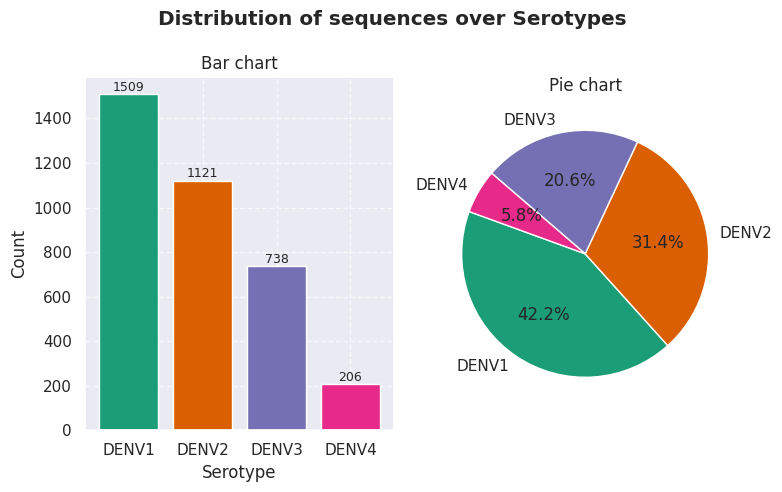

In [ ]:
#Let's plot
plot_distribution_serotypes(df_1234)

In [ ]:
# Plot the distribution of samples per year
def plot_distribution_year(df):

    # Convert Collection date to datetime
    df['Collection date'] = pd.to_datetime(df['Collection date'])

    df['Year'] = df['Collection date'].dt.year
    year_counts = df['Year'].value_counts().sort_index()

    plt.figure(figsize=(8, 6.1))

    #sns.set_style("whitegrid")
    #sns.set_theme()

    sns.barplot(x=year_counts.index, y=year_counts.values,alpha=1, hue=year_counts.index, palette='Dark2', legend=False)
    plt.title('Number of genomic sequences collected per year', fontsize=12,fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=90)
    plt.grid(linestyle='--', alpha=0.7)#axis='y',

    for i, v in enumerate(year_counts.values):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

    plt.tight_layout()
    #plt.savefig('dengue_samples_per_year.png', dpi=300)
    plt.savefig('/content/FIGURES/Seq_per_year.pdf', format='pdf')
    plt.show()

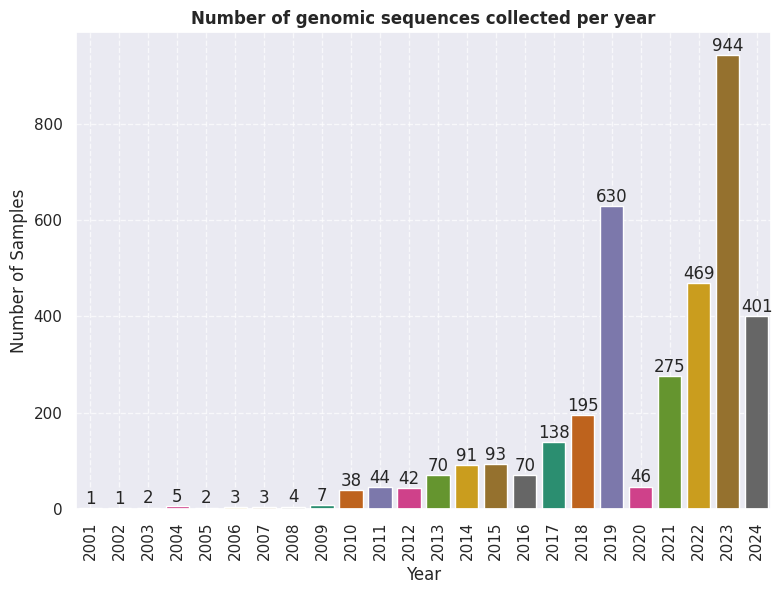

In [ ]:
# Plot the distribution of samples over year
plot_distribution_year(df_1234)

In [ ]:
def plot_distribution_lineages(df):
    # Group by serotype and lineage to get the counts
    lineage_counts = df.groupby(['Serotype', 'Lineage']).size().reset_index(name='count')

    # Sort by serotype and count
    lineage_counts = lineage_counts.sort_values(['Serotype', 'count'], ascending=[True, False])

    # Create a color palette for each serotype
    color_palette = {
        'DENV1': sns.color_palette("Reds_r", n_colors=1)[0],
        'DENV2': sns.color_palette("Blues_r", n_colors=1)[0],
        'DENV3': sns.color_palette("Greens_r", n_colors=1)[0],
        'DENV4': sns.color_palette("Purples_r", n_colors=1)[0]
    }

    # Set up the plot
    plt.figure(figsize=(10, 6.1))
    sns.set_theme()

    # Create the bar plot
    ax = sns.barplot(x='Lineage', y='count', hue='Serotype',alpha=1, data=lineage_counts, palette=color_palette)

    # Customize the plot
    plt.title('Distribution of sequences over Lineages', fontsize=12,fontweight='bold')
    plt.xlabel('Lineage', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.ylim(-10, 800)

    # Rotate x-axis labels
    plt.xticks(rotation=90, ha='center', fontsize=10)

    # Add value labels on top of each bar
    for i, v in enumerate(lineage_counts['count']):
        ax.text(i, v, str(v), ha='center', va='bottom', rotation=90, fontsize=10)

    # Adjust layout to prevent cutting off x-axis labels
    plt.tight_layout()

    # Save the figure as a PDF
    plt.savefig('/content/FIGURES/Seq_per_lineage.pdf', format='pdf')

    # Show the plot
    plt.show()

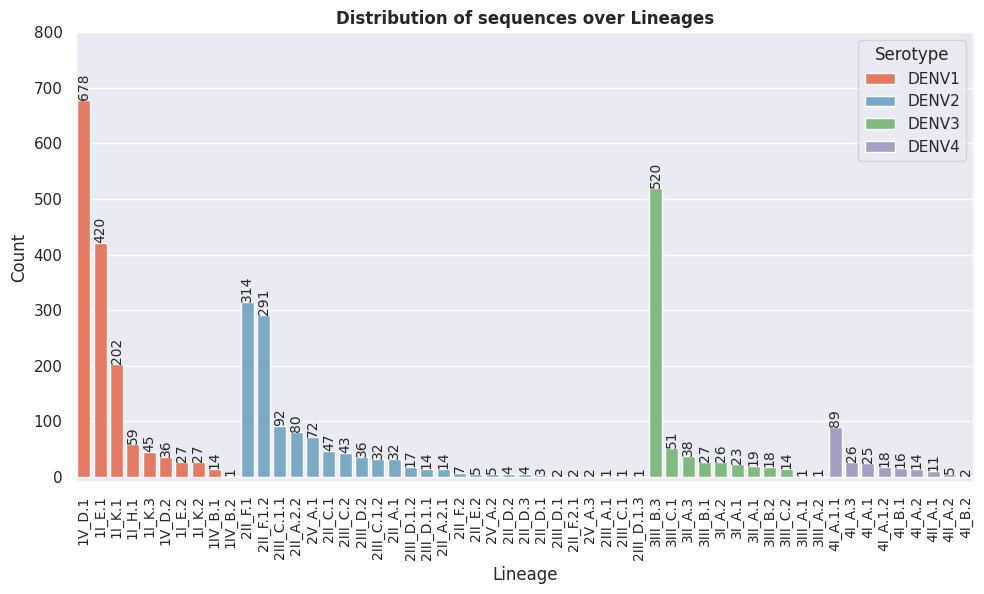

In [ ]:
# Let's plot
plot_distribution_lineages(df_1234)

**What if we display the percentage of each lineage?**

In [ ]:
# This function will display the percentage of each lineage in: 1) The serotype, 2) The whole dataset
def plot_lineages_percentages(df):

  # Calculate counts and percentages
  lineage_counts = df.groupby(['Serotype', 'Lineage']).size().reset_index(name='count')
  total_count = lineage_counts['count'].sum()

  # Calculate percentages
  lineage_counts['Percentage_in_serotype'] = lineage_counts.groupby('Serotype')['count'].transform(lambda x: x / x.sum() * 100)
  lineage_counts['Percentage_in_dataset'] = lineage_counts['count'] / total_count * 100

  # Sort the DataFrame
  lineage_counts = lineage_counts.sort_values(['Serotype', 'Percentage_in_serotype'], ascending=[True, False])

  # Create the table
  table = PrettyTable()
  table.field_names = ["Lineage", "% in Serotype", "% in Dataset"]
  table.align["Lineage"] = "l"
  table.align["% in Serotype"] = "r"
  table.align["% in Dataset"] = "r"

  # Add rows to the table
  for _, row in lineage_counts.iterrows():
      table.add_row([
          row['Lineage'],
          f"{row['Percentage_in_serotype']:.2f}%",
          f"{row['Percentage_in_dataset']:.2f}%"
      ])

  # Set table style
  table.border = True
  table.header = True
  table.padding_width = 1

  # Print the table
  print(table)

  # Save the table to a file
  #with open('lineage_percentages.txt', 'w') as f:
  #    f.write(table.get_string())

In [ ]:
# Display the different lineages percentages
plot_lineages_percentages(df_1234)

+------------+---------------+--------------+
| Lineage    | % in Serotype | % in Dataset |
+------------+---------------+--------------+
| 1V_D.1     |        44.93% |       18.97% |
| 1I_E.1     |        27.83% |       11.75% |
| 1I_K.1     |        13.39% |        5.65% |
| 1I_H.1     |         3.91% |        1.65% |
| 1I_K.3     |         2.98% |        1.26% |
| 1V_D.2     |         2.39% |        1.01% |
| 1I_E.2     |         1.79% |        0.76% |
| 1I_K.2     |         1.79% |        0.76% |
| 1IV_B.1    |         0.93% |        0.39% |
| 1IV_B.2    |         0.07% |        0.03% |
| 2II_F.1    |        28.01% |        8.79% |
| 2II_F.1.2  |        25.96% |        8.14% |
| 2III_C.1.1 |         8.21% |        2.57% |
| 2II_A.2.2  |         7.14% |        2.24% |
| 2V_A.1     |         6.42% |        2.01% |
| 2II_C.1    |         4.19% |        1.32% |
| 2III_C.2   |         3.84% |        1.20% |
| 2III_D.2   |         3.21% |        1.01% |
| 2III_C.1.2 |         2.85% |    

**Many classes have less than 1% in the dataset, what if we skip  all classes whose percentage in the dataset is less than 0.3%?, i.e. each lineage should appear at least 14 times in the whole dataset**

In [ ]:
# THis function will skip some very underepresented lineages coz some apear once, twice,...
def filter_lineages(df):
  # Calculate counts and percentages
  lineage_counts = df.groupby(['Serotype', 'Lineage']).size().reset_index(name='count')
  total_count = lineage_counts['count'].sum()

  # Calculate percentages
  lineage_counts['percentage_in_serotype'] = lineage_counts.groupby('Serotype')['count'].transform(lambda x: x / x.sum() * 100)
  lineage_counts['percentage_in_dataset'] = lineage_counts['count'] / total_count * 100

  # Identify lineages with less than 0.4% representation
  lineages_to_keep = lineage_counts[lineage_counts['percentage_in_dataset'] >= 0.3]['Lineage'].tolist()

  # Create a new DataFrame excluding lineages with less than 0.4% representation
  df_filtered = df[df['Lineage'].isin(lineages_to_keep)].copy()

  # Print information about the filtering process
  print(f"Original number of samples: {len(df)}")
  print(f"Number of samples after filtering: {len(df_filtered)}")
  print(f"Number of lineages: {len(lineage_counts)}")
  print(f"Number of lineages removed: {len(lineage_counts) - len(lineages_to_keep)}")
  print(f"\nLineages kept: {len(lineages_to_keep)}")
  for lineage in sorted(lineages_to_keep):
      percentage = lineage_counts[lineage_counts['Lineage'] == lineage]['percentage_in_dataset'].values[0]
      print(f"{lineage}: {percentage:.2f}%")

  #Save the filtered DataFrame to a new CSV file
  df_filtered.to_csv('/content/FINAL_DATASET/MERGED/filtered_dataset.csv', index=False)

  # Print the distribution of Serotype in the filtered dataset
  species_distribution = df_filtered['Serotype'].value_counts(normalize=True) * 100
  print("\nSpecies distribution in the filtered dataset:")
  for species, percentage in species_distribution.items():
      print(f"{species}: {percentage:.2f}%")

In [ ]:
# Let's display the obtained results
filter_lineages(df_1234)

Original number of samples: 3574
Number of samples after filtering: 3527
Number of lineages: 55
Number of lineages removed: 17

Lineages kept: 38
1IV_B.1: 0.39%
1I_E.1: 11.75%
1I_E.2: 0.76%
1I_H.1: 1.65%
1I_K.1: 5.65%
1I_K.2: 0.76%
1I_K.3: 1.26%
1V_D.1: 18.97%
1V_D.2: 1.01%
2III_C.1.1: 2.57%
2III_C.1.2: 0.90%
2III_C.2: 1.20%
2III_D.1.1: 0.39%
2III_D.1.2: 0.48%
2III_D.2: 1.01%
2II_A.1: 0.90%
2II_A.2.1: 0.39%
2II_A.2.2: 2.24%
2II_C.1: 1.32%
2II_F.1: 8.79%
2II_F.1.2: 8.14%
2V_A.1: 2.01%
3III_B.1: 0.76%
3III_B.2: 0.50%
3III_B.3: 14.55%
3III_C.1: 1.43%
3III_C.2: 0.39%
3II_A.1: 0.53%
3II_A.3: 1.06%
3I_A.1: 0.64%
3I_A.2: 0.73%
4II_A.1: 0.31%
4I_A.1: 0.70%
4I_A.1.1: 2.49%
4I_A.1.2: 0.50%
4I_A.2: 0.39%
4I_A.3: 0.73%
4I_B.1: 0.45%

Species distribution in the filtered dataset:
DENV1: 42.76%
DENV2: 30.73%
DENV3: 20.87%
DENV4: 5.64%


In [ ]:
df = pd.read_csv('/content/FINAL_DATASET/MERGED/filtered_dataset.csv')

In [ ]:
# @title
def plot_distribution_2d_serotypes(df):
    serotypes_counts = df['Serotype'].value_counts()

    # Create a dictionary of serotype counts
    serotypes = {
        'DENV1': serotypes_counts.get('DENV1', 0),
        'DENV2': serotypes_counts.get('DENV2', 0),
        'DENV3': serotypes_counts.get('DENV3', 0),
        'DENV4': serotypes_counts.get('DENV4', 0)
    }

    # Calculate percentages
    total_counts = sum(serotypes.values())
    percentages = [(count / total_counts) * 100 for count in serotypes.values()]

    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle('Distribution of Sequences over Serotypes',fontsize=12, fontweight='bold')

    # Bar chart
    bars = ax.bar(serotypes.keys(), serotypes.values(), color=sns.color_palette('Dark2', n_colors=len(serotypes)))

    ax.spines[['top', 'right']].set_visible(True)
    ax.set_xlabel('Serotype')
    ax.set_ylabel('Frequency')
    ax.grid(linestyle="--", alpha=1.0)

    # Adding frequency and percentage labels
    for bar, percent in zip(bars, percentages):
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.0f} ({percent:.1f}%)', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('/content/FIGURES/Seq_per_serotype_2D.pdf', format='pdf')
    plt.show()

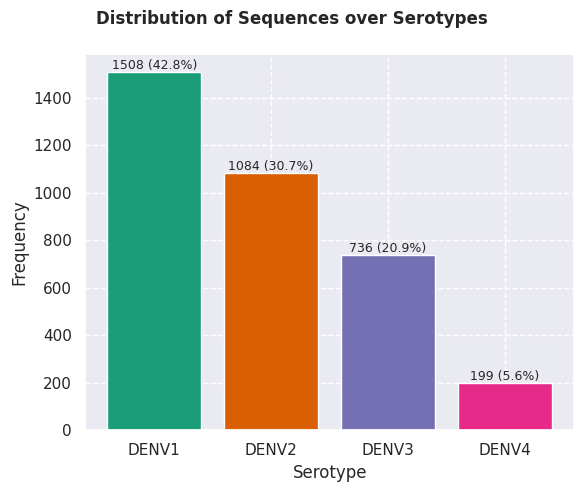

In [ ]:
#Let's plot
plot_distribution_2d_serotypes(df)

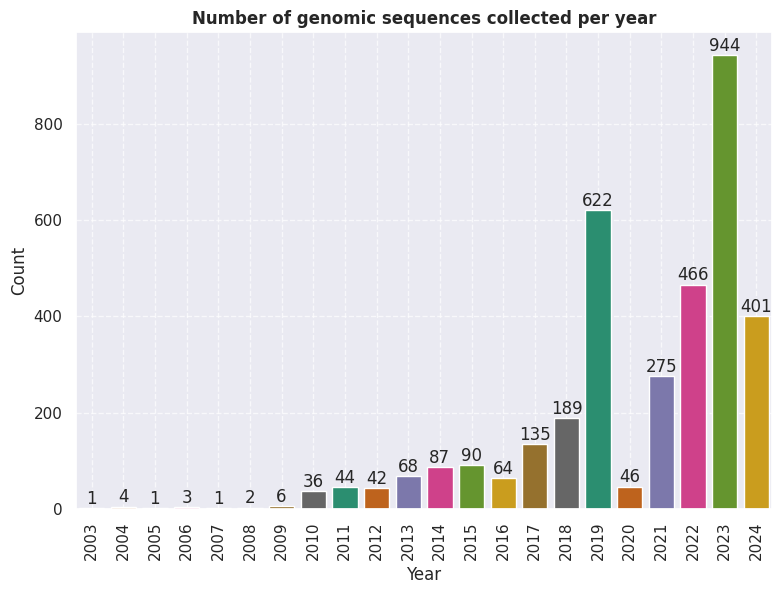

In [ ]:
# Plot the distribution of samples over year
plot_distribution_year(df)

In [ ]:
serotypes_counts = df['Serotype'].value_counts()

# Create a dictionary of serotype counts
serotypes = {
    'DENV1': serotypes_counts.get('DENV1', 0),
    'DENV2': serotypes_counts.get('DENV2', 0),
    'DENV3': serotypes_counts.get('DENV3', 0),
    'DENV4': serotypes_counts.get('DENV4', 0)
}

# Calculate percentages
total_counts = sum(serotypes.values())
percentages = [(count / total_counts) * 100 for count in serotypes.values()]


# @title
def plot_distribution_2d_lineages(df):
    # Group by serotype and lineage to get the counts
    lineage_counts = df.groupby(['Serotype', 'Lineage']).size().reset_index(name='count')

    # Sort by serotype and count
    lineage_counts = lineage_counts.sort_values(['Serotype', 'count'], ascending=[True, False])

    # Create a color palette for each serotype
    color_palette = sns.color_palette('Dark2', n_colors=4)


    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.suptitle('Sequence Distribution Across Serotypes and Lineages', fontweight='bold')



    sns.set_theme()

    # Create the bar plot
    ax = sns.barplot(x='Lineage', y='count', hue='Serotype',alpha=1, data=lineage_counts, palette=color_palette)

    # Customize the plot
    ax.legend(title='Serotype', bbox_to_anchor=(1.01, 0.6), loc="upper left", frameon=False)
    plt.xlabel('Lineage', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(linestyle='--', alpha=1.0)
    plt.ylim(-10, 715)

    # Rotate x-axis labels
    plt.xticks(rotation=90, ha='center', fontsize=10)

    # Add value labels on top of each bar
    for i, v in enumerate(lineage_counts['count']):
        ax.text(i, v, str(v), ha='center', va='bottom', rotation=90, fontsize=10)

    # Lines
    ax.axvline(8.5, linestyle='--', color='gray')
    ax.axvline(21.5, linestyle='--', color='gray')
    ax.axvline(30.5, linestyle='--', color='gray')

    # Adjust layout to prevent cutting off x-axis labels
    plt.tight_layout()

    # Save the figure as a PDF
    plt.savefig('/content/FIGURES/Seq_per_2d_final_lineage.pdf', format='pdf')

    # Show the plot
    plt.show()

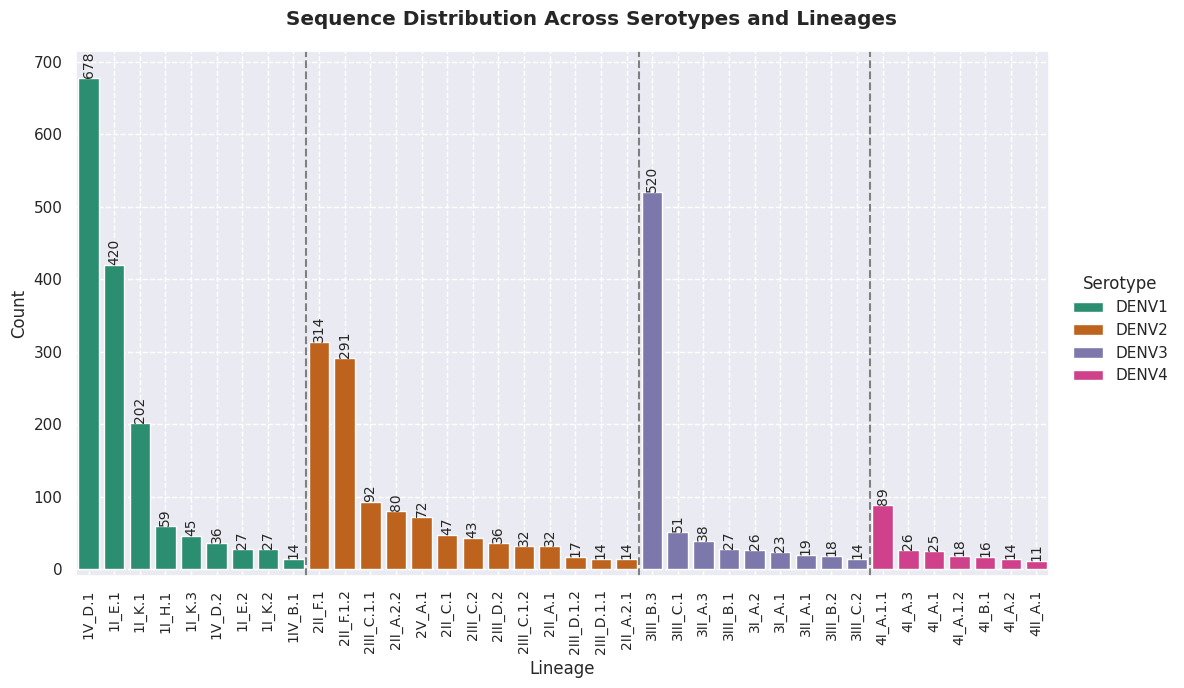

In [ ]:
# Plot the lineages distribution
plot_distribution_2d_lineages(df)

`Fistly we will remove all letters which don't belong to the DNA alphabet` ($𝛀$):$$𝛀 = \{A,C,G,T\}$$


Are they some ambiguous nucleotides in  the dataset?

In [ ]:
# Concatenate all sequences into one large string
all_sequences = df['Sequence'].str.cat(sep='').upper()

# Convert the concatenated string into a set of unique characters
unique_letters = set(all_sequences)

print(f"Unique letters in the 'Sequence' column: {unique_letters}")

Unique letters in the 'Sequence' column: {'Y', 'T', 'N', 'G', 'S', 'K', 'A', 'R', 'M', 'V', 'D', 'B', 'W', 'C'}


In [ ]:
# Drop sequences with ambiguous nucleotides
dna_alphabet = ['A', 'C', 'G', 'T']
df['Sequence'] = df['Sequence'].apply(lambda seq: ''.join([n for n in seq if n in dna_alphabet]))
#add a column which compute the len of each row in this dataframe
df['Length'] = df['Sequence'].apply(lambda seq: len(seq))
# Order of the columns
df = df[['Sequence','Length','Serotype', 'Lineage','Collection date', 'Submission date', 'Location']]

In [ ]:
# Save this final dataset
df.to_csv('/content/FINAL_DATASET/MERGED/df_final_version_cleaned_dengue_sequences.csv', index=False)

**F. FINAL CLEANED DATASET**

In [ ]:
#df = pd.read_csv('/content/FINAL_DATASET/MERGED/dffinal_cleaned_sequences_dataset.csv')
df = pd.read_csv('/content/FINAL_DATASET/MERGED/df_final_version_cleaned_dengue_sequences.csv')

In [ ]:
# Cheking:
df.head()

,Sequence,Length,Serotype,Lineage,Collection date,Submission date,Location
0,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,10580,DENV3,3III_B.3,2024-03-11,2024-08-08,North America / USA / Florida
1,CGTAGTTATAACAGTTTTTTCATTCGAGAGCAGATCTCTGATGAAT...,10568,DENV2,2II_F.1,2019-08-14,2020-01-10,Asia / China / Guangdong
2,CAAGAACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAG...,10054,DENV1,1V_D.1,2024-05-03,2024-08-02,South America / Brazil / Pernambuco / Belem do...
3,GTTAGTCTACGTGGACCGACAAAGACAGATTCTTTGAGGAAGCTAA...,10494,DENV2,2II_F.1,2023-09-08,2024-06-24,Asia / Bangladesh / Dhaka
4,AGTTGTTAGTCTACGTGGACCGACAAAGACAGATTCTTTGAGGAAG...,10423,DENV2,2II_F.1.2,2024-02-19,2024-05-08,South America / Brazil / Sao Paulo / Rio Claro


In [ ]:
max_length = df['Length'].max()
def plot_length_distribution(df,lenth=max_length):
    sns.histplot(df['Length'], kde=True, color='teal', alpha=1.0)
    plt.axvline(lenth, color='red', linestyle='--', linewidth=2,label=f'Maximum Length : {max_length} nucleotides')
    plt.legend()
    plt.title('Distribution of Sequence Lengths',fontsize=12,fontweight='bold')
    plt.xlabel('Length')
    plt.ylabel('Frequency')
    plt.grid(linestyle='--', alpha=0.5)
    plt.savefig('/content/FIGURES/Length_distribution.pdf', format='pdf')
    plt.show()

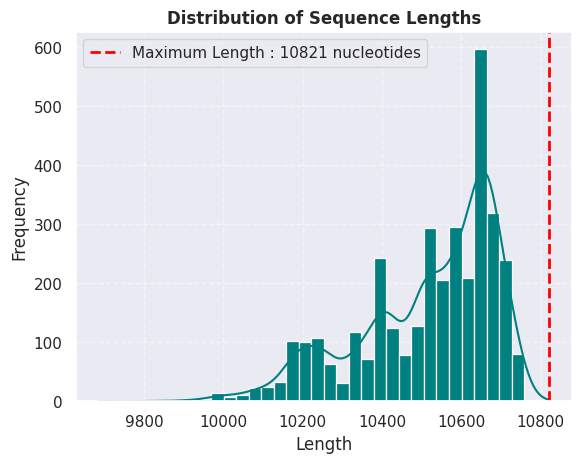

In [ ]:
plot_length_distribution(df)

In [ ]:
# Is the  lenth constant?
df['Length'].describe().T

,Length
count,3527.000000
mean,10514.581514
std,172.945523
min,9685.000000
25%,10410.000000
50%,10567.000000
75%,10654.000000
max,10821.000000


In [ ]:
# Infos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3527 entries, 0 to 3526
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sequence         3527 non-null   object
 1   Length           3527 non-null   int64 
 2   Serotype         3527 non-null   object
 3   Lineage          3527 non-null   object
 4   Collection date  3527 non-null   object
 5   Submission date  3527 non-null   object
 6   Location         3527 non-null   object
dtypes: int64(1), object(6)
memory usage: 193.0+ KB


# `I.3. Main idea behind the k-mer encoding`

In [ ]:
#NLP
from sklearn.feature_extraction.text import CountVectorizer

document = ["One Geek helps Two Geeks",
			"Two Geeks help Four Geeks",
			"Each Geek helps many other Geeks at GeeksforGeeks"]

# Create a Vectorizer Object
vectorizer = CountVectorizer()

vectorizer.fit(document)

# Printing the identified Unique words along with their indices
print("Vocabulary: ", vectorizer.vocabulary_)
print("Sorted vocabulary: ", sorted(vectorizer.vocabulary_.items(), key=lambda item: item[1]))

# Encode the Document
vector = vectorizer.transform(document)

# Summarizing the Encoded Texts
print("Encoded Document is:")
print(vector.toarray())

Vocabulary:  {'one': 9, 'geek': 3, 'helps': 7, 'two': 11, 'geeks': 4, 'help': 6, 'four': 2, 'each': 1, 'many': 8, 'other': 10, 'at': 0, 'geeksforgeeks': 5}
Sorted vocabulary:  [('at', 0), ('each', 1), ('four', 2), ('geek', 3), ('geeks', 4), ('geeksforgeeks', 5), ('help', 6), ('helps', 7), ('many', 8), ('one', 9), ('other', 10), ('two', 11)]
Encoded Document is:
[[0 0 0 1 1 0 0 1 0 1 0 1]
 [0 0 1 0 2 0 1 0 0 0 0 1]
 [1 1 0 1 1 1 0 1 1 0 1 0]]


# `I.4. t-SNE Vizualization`

In [ ]:
def plot_tsne(df, k=3):
    # Function to convert sequence to k-mer frequencies (normalized counts)
    def seq_to_kmer_freq(seq, k=k):
        kmer_count = Counter([''.join(seq[i:i+k]) for i in range(len(seq)-k+1)])
        total_kmers = sum(kmer_count.values())
        return {kmer: count / total_kmers for kmer, count in kmer_count.items()}

    # Convert sequences to k-mer frequencies
    kmer_counts = df['Sequence'].apply(seq_to_kmer_freq)

    # Convert k-mer frequencies to a DataFrame
    kmer_df = pd.DataFrame.from_records(kmer_counts).fillna(0)

    # Perform PCA for dimensionality reduction
    pca = PCA(n_components=50)
    pca_result = pca.fit_transform(kmer_df)

    # Perform t-SNE on PCA results
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(pca_result)

    # Plotting
    sns.set_theme()

    # Create a scatter plot of t-SNE results
    plt.figure(figsize=(12, 10))

    # Define colors for serotypes using Dark2 palette
    unique_serotypes = sorted(df['Serotype'].unique())  # Sort to ensure 1-2-3-4 order
    color_palette = sns.color_palette('Dark2', n_colors=len(unique_serotypes))
    color_dict = dict(zip(unique_serotypes, color_palette))

    # Plot each serotype with different color and marker
    for serotype in unique_serotypes:
        mask = np.where(df['Serotype'] == serotype)  # Get the index mask
        plt.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=[color_dict[serotype]],
                    marker='o', edgecolors='k',
                    label=serotype, s=50, alpha=1.0)

    plt.title(f't-SNE Visualization of sequences using {k}-mers encoding', fontweight='bold', fontsize=15)
    plt.xlabel('t-SNE 1', fontsize=12)
    plt.ylabel('t-SNE 2', fontsize=12)

    # Create legend with proper order
    plt.legend(title='Serotype', loc="upper right", fontsize=12)
    plt.grid(linestyle="--", alpha=1.0)

    # Save the plot
    plt.savefig('/content/FIGURES/tt6-SNE.pdf', format='pdf')
    plt.show()

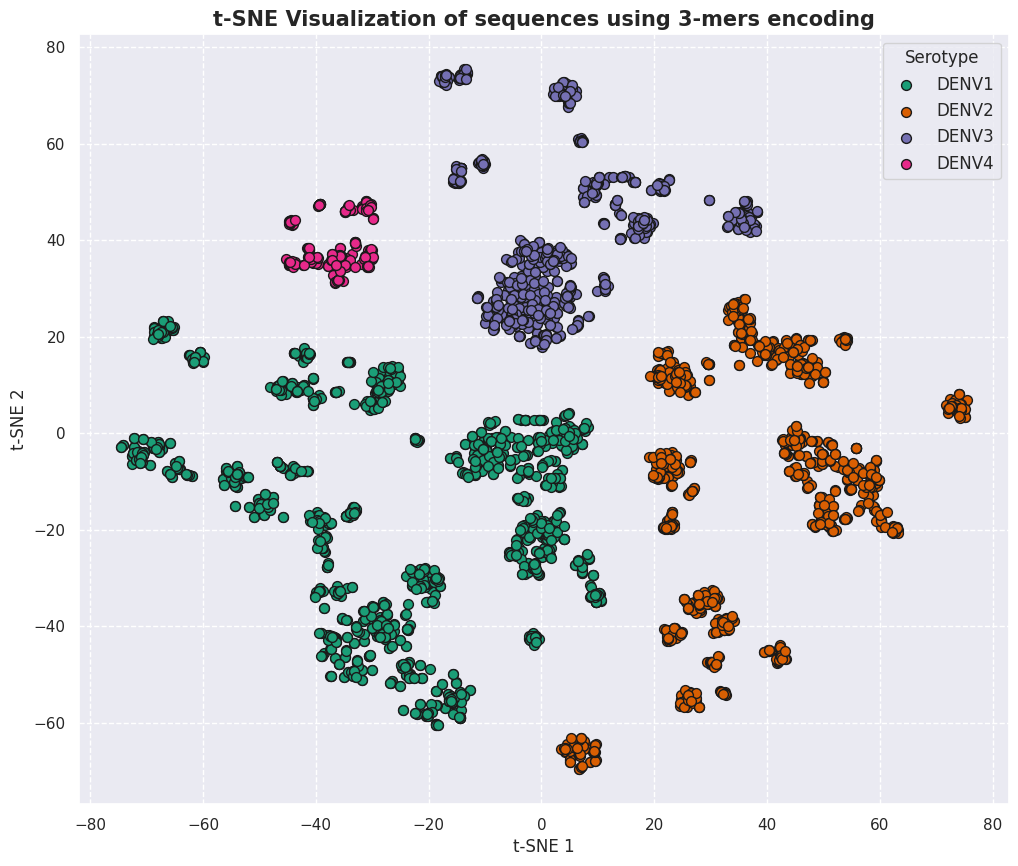

In [ ]:
# Plot t-SNE
kmer=3
plot_tsne(df,k=kmer)

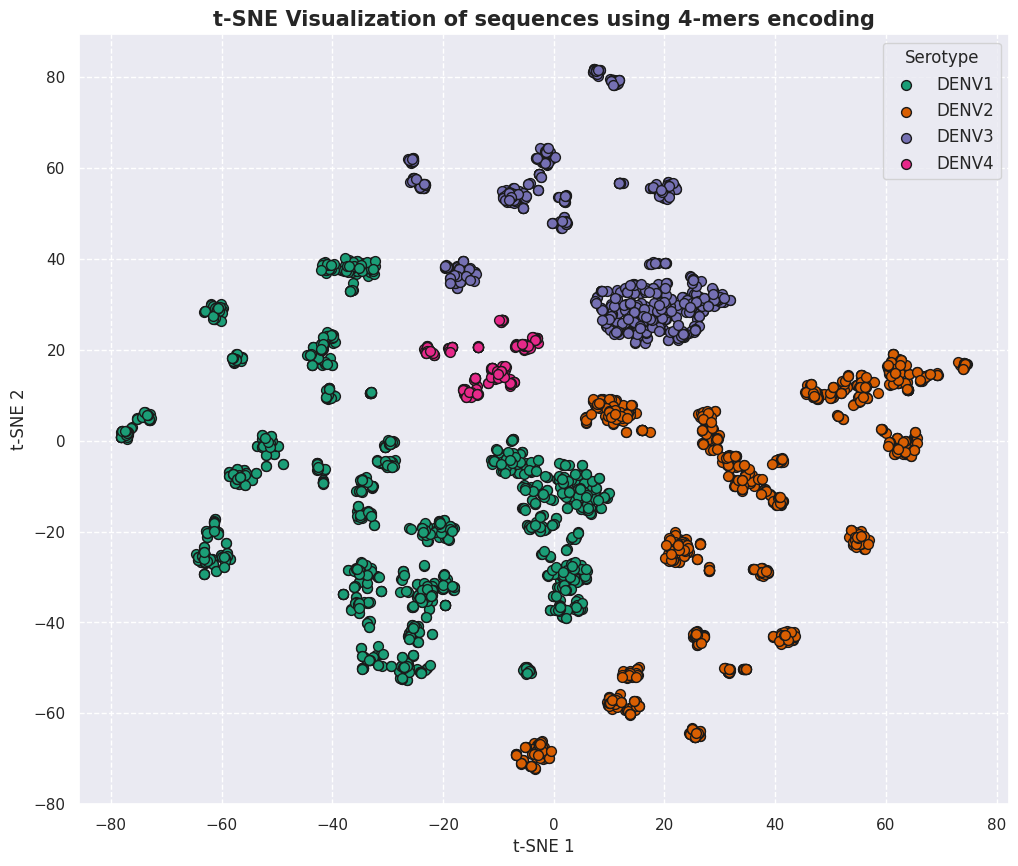

In [ ]:
# Plot t-SNE
kmer=4
plot_tsne(df,k=kmer)

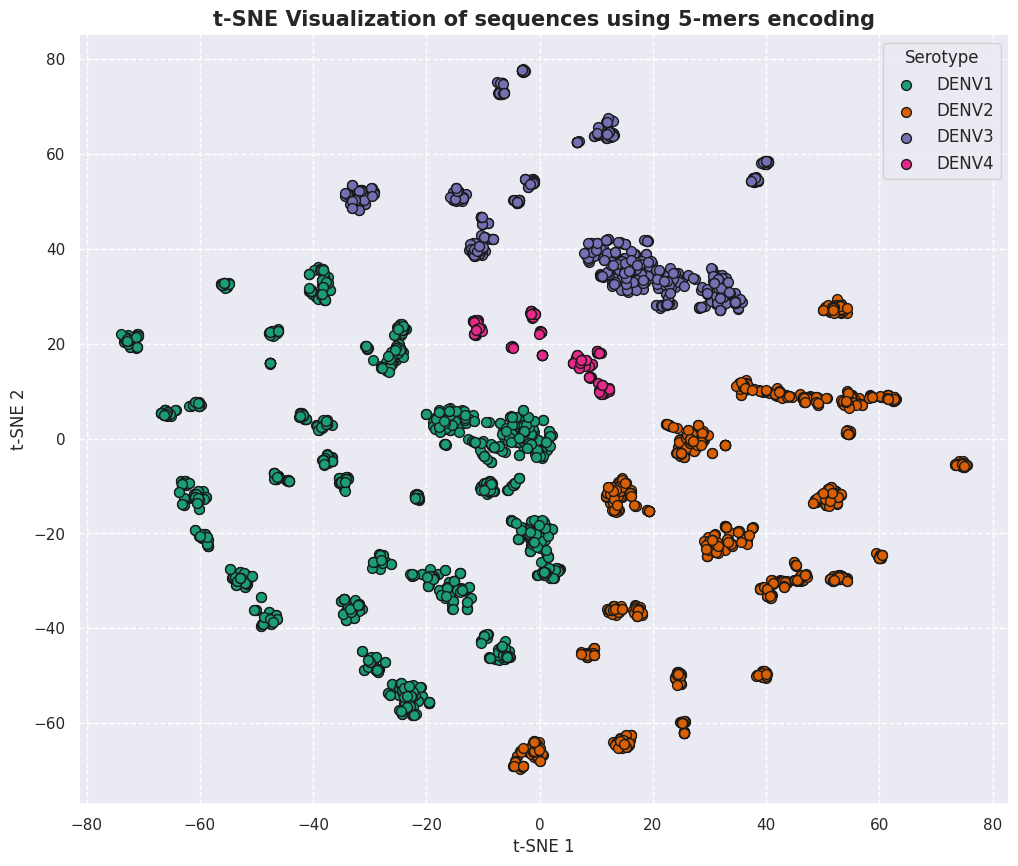

In [ ]:
# Plot t-SNE
kmer=5
plot_tsne(df,k=kmer)

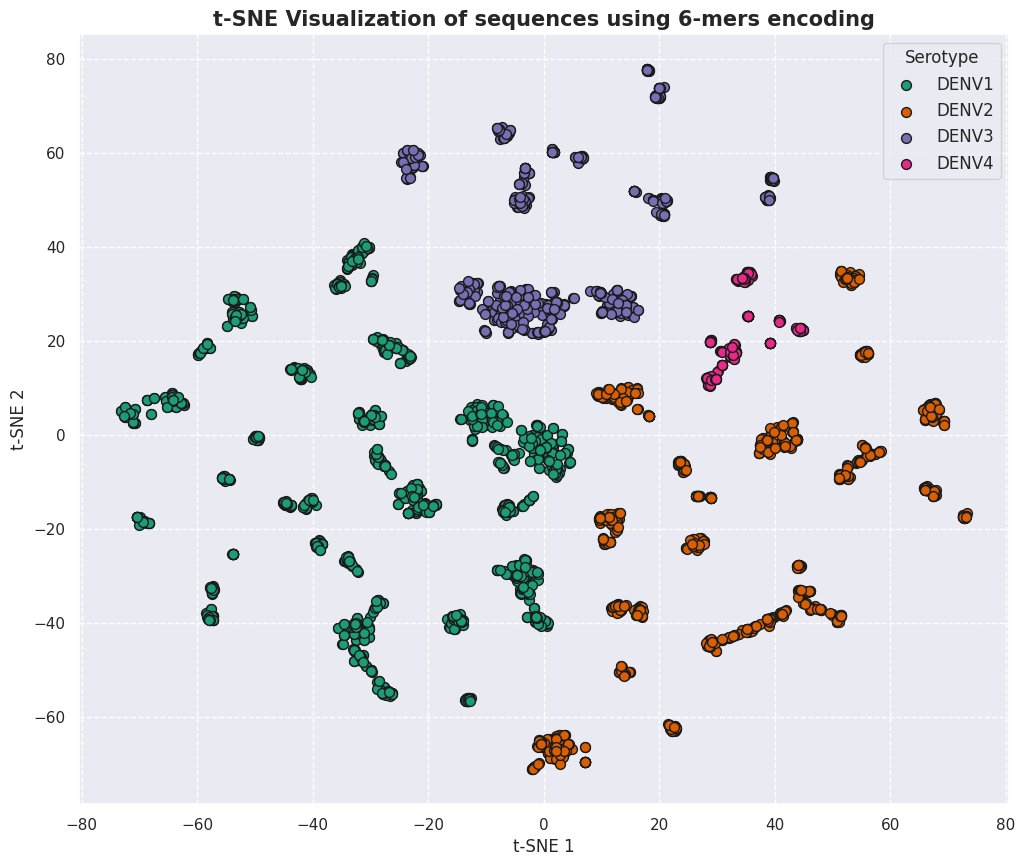

In [ ]:
# Plot t-SNE
kmer=6
plot_tsne(df,k=kmer)

# `I.5.Visualization of the FCGR in the usual` $\mathbb{R}^{2}$ `plan`

In [ ]:
# Function to compute FCGR for a given sequence and resolution
def fcgr(sequence, resolution):
    # Coordinates of the nucleotides
    coord_map = {
        'A': (0, 0),
        'C': (0, 1),
        'G': (1, 1),
        'T': (1, 0)
    }

    # Starting point (center of the unit square)
    X = 0.5
    Y = 0.5

    # Create a grid for FCGR
    fcgr_grid = np.zeros((resolution, resolution))

    # Recursive calculation of FCGR
    for nucleotide in sequence:
        if nucleotide in coord_map:
            X = 0.5 * (X + coord_map[nucleotide][0])
            Y = 0.5 * (Y + coord_map[nucleotide][1])

        # Convert (X, Y) to pixel coordinates on the grid (flip X and Y for correct orientation)
        x_pixel = int(Y * resolution)
        y_pixel = int(X * resolution)

        # Increment the count at the corresponding pixel
        fcgr_grid[x_pixel, y_pixel] += 1

    return fcgr_grid

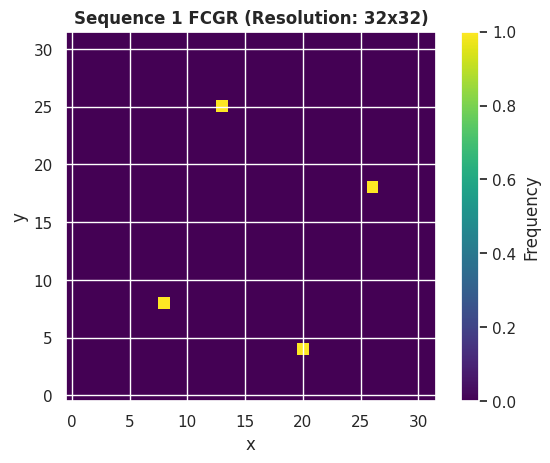

In [ ]:
# Sequence 1
sequence1 = "ATGC"
resolution = 32
fcgr_result = fcgr(sequence1, resolution)

# Plot the FCGR with corrected orientation
plt.imshow(fcgr_result, cmap='viridis', interpolation='nearest', origin='lower')
plt.colorbar(label='Frequency')
plt.title(f'Sequence 1 FCGR (Resolution: {resolution}x{resolution})',fontweight='bold')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig("/content/FIGURES/rotated_FCGR1.pdf")
plt.show()

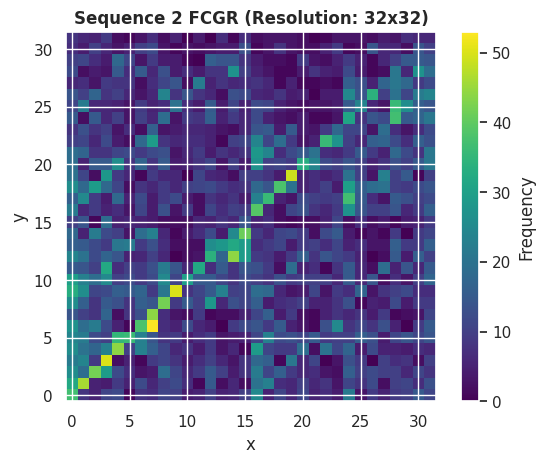

In [ ]:
# Sequence 2
sequence2 = df['Sequence'].iloc[0]
resolution = 32
fcgr_result = fcgr(sequence2, resolution)

# Plot the FCGR with corrected orientation
plt.imshow(fcgr_result, cmap='viridis', interpolation='nearest', origin='lower')
plt.colorbar(label='Frequency')
plt.title(f'Sequence 2 FCGR (Resolution: {resolution}x{resolution})',fontweight='bold')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig("/content/FIGURES/rotated_FCGR2.pdf")
plt.show()